## Model predykcji popytu i optymalizacji cen (Dynamic Pricing)

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization, GRU, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import subprocess
import sys
import optuna
from optuna.samplers import TPESampler
import gc
import warnings
warnings.filterwarnings('ignore')

print("Konfiguracja GPU...")
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]
        )
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"Wykryto {len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(f"Błąd konfiguracji GPU: {e}")
        tf.config.set_visible_devices([], 'GPU')
else:
    print("Brak dostępnych GPU - używam CPU")

print("\nTensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

2026-03-31 15:19:12.184862: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 15:19:12.227325: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-31 15:19:12.227364: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-31 15:19:12.229091: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 15:19:12.240658: I tensorflow/core/platform/cpu_feature_guar

Konfiguracja GPU...
Wykryto 1 Physical GPUs, 1 Logical GPUs

TensorFlow version: 2.15.0
Num GPUs Available: 1


2026-03-31 15:19:16.295077: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 15:19:16.595619: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 15:19:16.595744: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 15:19:16.595758: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-03-31 15:19:16.598259: I external/lo

### Wczytywanie i Preprocessing Danych

**Cel:** Wczytać dane sprzedażowe, wyczyścić, zagregować i przygotować cechy czasowe.

**Kroki:**
1. Wczytaj CSV, usuń zera
2. Agreguj po dniach i produktach
3. Wybierz produkt o największej zmienności
4. Dodaj cechy czasowe (dzień tygodnia, miesiąc, trend)
5. Oblicz średnie kroczące (MA-7, MA-30)

In [2]:
df = pd.read_csv('sales.csv')
print(f"\nRozmiar surowych danych: {df.shape}")
print(f"Kolumny: {list(df.columns)}")

df['date'] = pd.to_datetime(df['date'])

print(f"\n1. USUWANIE ZER")
print(f"   Wiersze ze sprzedażą = 0: {(df['sales'] == 0).sum()}")
df = df[df['sales'] > 0].copy()
print(f"   Po usunięciu zer: {len(df)} wierszy")

print(f"\n2. AGREGACJA PO DNIACH")
print(f"   Liczba unikalnych sklepów: {df['store_id'].nunique()}")
print(f"   Liczba unikalnych produktów: {df['product_id'].nunique()}")

df_agg = df.groupby(['date', 'product_id']).agg({
    'sales': 'sum',
    'price': 'mean',
    'revenue': 'sum'
}).reset_index()

df_agg['qty_sold'] = df_agg['revenue'] / df_agg['price']
print(f"   Po agregacji: {len(df_agg)} wierszy")

print(f"\n3. WYBÓR PRODUKTU")
product_counts = df_agg['product_id'].value_counts()
top_product = product_counts.index[0]
print(f"   Top produkt: {top_product}")
print(f"   Liczba dni sprzedaży: {product_counts.iloc[0]}")

df_agg = df_agg[df_agg['product_id'] == top_product].copy()
df_agg = df_agg.sort_values('date').reset_index(drop=True)

print(f"\n4. CECHY CZASOWE")
df_agg['day_of_week'] = df_agg['date'].dt.dayofweek
df_agg['month'] = df_agg['date'].dt.month
df_agg['quarter'] = df_agg['date'].dt.quarter
df_agg['day_of_year'] = df_agg['date'].dt.dayofyear
df_agg['week_of_year'] = df_agg['date'].dt.isocalendar().week
df_agg['is_weekend'] = (df_agg['day_of_week'] >= 5).astype(int)
df_agg['trend'] = np.arange(len(df_agg))
df_agg['sales_ma_7d'] = df_agg['sales'].rolling(window=7, min_periods=1).mean()
df_agg['sales_ma_30d'] = df_agg['sales'].rolling(window=30, min_periods=1).mean()
df_agg['price_ma_30d'] = df_agg['price'].rolling(window=30, min_periods=1).mean()
df_agg['price_ratio'] = df_agg['price'] / df_agg['price_ma_30d']

promo_cols = [col for col in df_agg.columns if 'promo' in col.lower()]
df_agg = df_agg.drop(columns=promo_cols, errors='ignore')

print(f"\n5. STATYSTYKI")
print(f"  Sales - Min: {df_agg['sales'].min():.2f}, Max: {df_agg['sales'].max():.2f}, Mean: {df_agg['sales'].mean():.2f}")
print(f"  Price - Min: {df_agg['price'].min():.2f}, Max: {df_agg['price'].max():.2f}")

corr_price_sales = df_agg['price'].corr(df_agg['sales'])
print(f"  Korelacja Price-Sales: {corr_price_sales:.4f}")
print(f"  Zakres dat: {df_agg['date'].min()} do {df_agg['date'].max()}")
print(f"  Liczba dni: {len(df_agg)}")


Rozmiar surowych danych: (19454838, 13)
Kolumny: ['product_id', 'store_id', 'date', 'sales', 'revenue', 'stock', 'price', 'promo_type_1', 'promo_bin_1', 'promo_type_2', 'promo_bin_2', 'promo_discount_2', 'promo_discount_type_2']

1. USUWANIE ZER
   Wiersze ze sprzedażą = 0: 15074394
   Po usunięciu zer: 3189682 wierszy

2. AGREGACJA PO DNIACH
   Liczba unikalnych sklepów: 144
   Liczba unikalnych produktów: 629
   Po agregacji: 278484 wierszy

3. WYBÓR PRODUKTU
   Top produkt: P0185
   Liczba dni sprzedaży: 1033

4. CECHY CZASOWE

5. STATYSTYKI
  Sales - Min: 22.00, Max: 96.00, Mean: 53.24
  Price - Min: 0.75, Max: 1.00
  Korelacja Price-Sales: -0.2452
  Zakres dat: 2017-01-02 00:00:00 do 2019-10-31 00:00:00
  Liczba dni: 1033


### Analiza Trendu i Sezonowości

**Cel:** Rozłożyć szereg czasowy na komponenty (trend, sezonowość, szum).

**Metryki:**
- **Siła trendu** (0-1) - jak dużo zmienności wyjaśnia trend
- **Siła sezonowości** (0-1) - jak dużo zmienności wyjaśnia powtarzalny wzorzec


1. DEKOMPOZYCJA SZEREGU CZASOWEGO
   Długość okresu: 1033 dni (2.8 lat)
   Siła trendu: 0.3943
   Siła sezonowości: 0.8142

2. SEZONOWOŚĆ - DNI TYGODNIA
      mean    std  count
Pon  53.58   8.50    148
Wto  51.41   9.38    148
Śro  50.07   7.76    148
Czw  51.01   7.31    148
Pią  52.53   9.60    147
Sob  55.27   8.02    147
Nie  58.86  10.56    147

3. SEZONOWOŚĆ - MIESIĄCE
        mean    std
month              
1      55.76  10.48
2      57.02   8.05
3      53.41   7.27
4      55.63   8.28
5      53.29   7.18
6      53.80  10.59
7      56.41   8.63
8      52.15   9.88
9      47.81   8.21
10     48.95   8.76
11     49.63   7.00
12     54.48   9.90


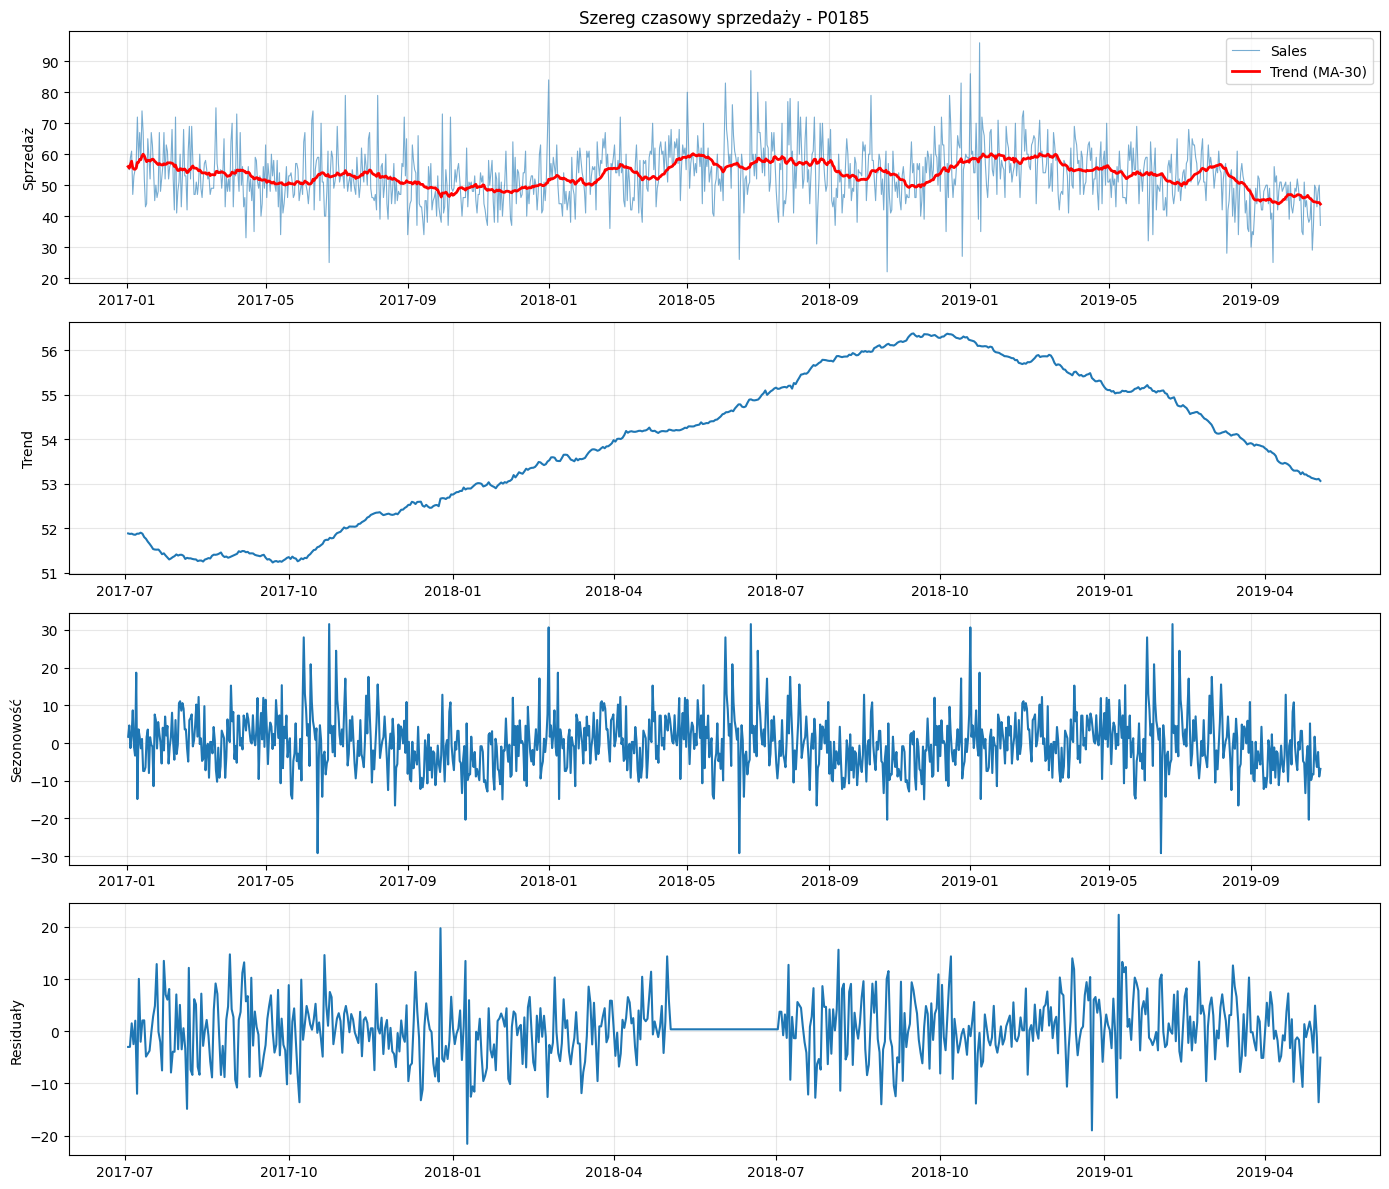

In [3]:
ts = df_agg[['date', 'sales', 'price']].set_index('date')

print(f"\n1. DEKOMPOZYCJA SZEREGU CZASOWEGO")
print(f"   Długość okresu: {len(ts)} dni ({len(ts)/365:.1f} lat)")

try:
    decomposition = seasonal_decompose(ts['sales'], model='additive', period=365)
    trend_std = decomposition.trend.std()
    seasonal_std = decomposition.seasonal.std()
    residual_std = decomposition.resid.std()
    
    seasonal_strength = 1 - (residual_std**2 / (seasonal_std + residual_std)**2)
    trend_strength = 1 - (residual_std**2 / (trend_std + residual_std)**2)
    
    print(f"   Siła trendu: {trend_strength:.4f}")
    print(f"   Siła sezonowości: {seasonal_strength:.4f}")
except Exception as e:
    print(f"   Dekompozycja nie powiodła się: {e}")
    decomposition = None

print(f"\n2. SEZONOWOŚĆ - DNI TYGODNIA")
dow_stats = df_agg.groupby('day_of_week')['sales'].agg(['mean', 'std', 'count'])
dow_names = ['Pon', 'Wto', 'Śro', 'Czw', 'Pią', 'Sob', 'Nie']
dow_stats.index = dow_names
print(dow_stats.round(2))

print(f"\n3. SEZONOWOŚĆ - MIESIĄCE")
month_stats = df_agg.groupby('month')['sales'].agg(['mean', 'std'])
print(month_stats.round(2))

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(df_agg['date'], df_agg['sales'], label='Sales', alpha=0.6, linewidth=0.8)
axes[0].plot(df_agg['date'], df_agg['sales_ma_30d'], label='Trend (MA-30)', color='red', linewidth=2)
axes[0].set_ylabel('Sprzedaż')
axes[0].set_title(f'Szereg czasowy sprzedaży - {top_product}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if decomposition is not None:
    axes[1].plot(decomposition.trend.index, decomposition.trend)
    axes[1].set_ylabel('Trend')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(decomposition.seasonal.index, decomposition.seasonal)
    axes[2].set_ylabel('Sezonowość')
    axes[2].grid(True, alpha=0.3)
    
    axes[3].plot(decomposition.resid.index, decomposition.resid)
    axes[3].set_ylabel('Residuały')
    axes[3].grid(True, alpha=0.3)
else:
    dow_avg = df_agg.groupby('day_of_week')['sales'].mean()
    axes[1].bar(range(7), dow_avg.values, color='skyblue')
    axes[1].set_xticks(range(7))
    axes[1].set_xticklabels(dow_names)
    axes[1].set_ylabel('Średnia sprzedaż')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    month_avg = df_agg.groupby('month')['sales'].mean()
    axes[2].plot(month_avg.index, month_avg.values, marker='o', linewidth=2)
    axes[2].set_ylabel('Średnia sprzedaż')
    axes[2].grid(True, alpha=0.3)
    
    axes[3].scatter(df_agg['price'], df_agg['sales'], alpha=0.3, s=10)
    axes[3].set_xlabel('Cena')
    axes[3].set_ylabel('Sprzedaż')
    axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trend_seasonality_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

### Przygotowanie Danych do Modelu

**Cel:** Przekształcić dane w format dla ML.

**Kroki:**
1. Normalizacja MinMax (0-1)
2. Tworzenie sekwencji (lookback=14 dni)
3. Podział train/test (80/20)

In [4]:
from sklearn.preprocessing import MinMaxScaler

print(f"\n  PRZYGOTOWANIE CECH")
feature_cols = ['sales', 'price', 'day_of_week', 'month', 'week_of_year', 
                'is_weekend', 'trend', 'sales_ma_7d', 'price_ratio']

X_data = df_agg[feature_cols].copy()
y_data = df_agg['sales'].copy()
print(f"   Cechy: {len(feature_cols)} zmiennych, Próbki: {len(X_data)}")

print(f"\n  NORMALIZACJA")
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data.values.reshape(-1, 1)).flatten()

print(f"\n  TWORZENIE SEKWENCJI (Lookback=14)")
def create_sequences(X, y, lookback=14):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i+lookback, :])
        y_seq.append(y[i+lookback])
    return np.array(X_seq), np.array(y_seq)

lookback = 14
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback=lookback)
print(f"   Kształt X_seq: {X_seq.shape}, y_seq: {y_seq.shape}")

print(f"\n  PODZIAŁ TRAIN/TEST")
train_size = int(len(X_seq) * 0.8)
X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_test, y_test = X_seq[train_size:], y_seq[train_size:]
print(f"   Train: {len(X_train)}, Test: {len(X_test)}")


  PRZYGOTOWANIE CECH
   Cechy: 9 zmiennych, Próbki: 1033

  NORMALIZACJA

  TWORZENIE SEKWENCJI (Lookback=14)
   Kształt X_seq: (1019, 14, 9), y_seq: (1019,)

  PODZIAŁ TRAIN/TEST
   Train: 815, Test: 204


### Skanowanie Produktów

**Cel:** Wybrać produkt najlepszy do modelowania dynamic pricing.

**Metryki oceny:**
- **CV (zmienność)** - std/mean, ideał: 0.3-0.5
- **Korelacja cena-sprzedaż** - czy cena wpływa na popyt
- **Sezonowość** - czy są powtarzające się wzorce

**Score = 2×CV + |korelacja| + 0.5×sezonowość**

In [5]:
df_all = pd.read_csv('sales.csv')
df_all['date'] = pd.to_datetime(df_all['date'])
df_all = df_all[df_all['sales'] > 0].copy()
df_all_agg = df_all.groupby(['date', 'product_id']).agg({
    'sales': 'sum', 'price': 'mean', 'revenue': 'sum'
}).reset_index()

print(f"\nDostępnych produktów: {df_all_agg['product_id'].nunique()}")

results = []
for product in df_all_agg['product_id'].unique()[:100]:
    df_prod = df_all_agg[df_all_agg['product_id'] == product].copy()
    if len(df_prod) < 100:
        continue
    
    sales_mean, sales_std = df_prod['sales'].mean(), df_prod['sales'].std()
    cv = sales_std / sales_mean if sales_mean > 0 else 0
    corr = df_prod['price'].corr(df_prod['sales'])
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(range(len(df_prod)), df_prod['sales'])
    trend_r2 = r_value ** 2
    
    try:
        seasonality_var = (df_prod['sales'].iloc[:7].std() + df_prod['sales'].iloc[-7:].std()) / 2
    except:
        seasonality_var = 0
    
    results.append({
        'product': product, 'days': len(df_prod), 'sales_mean': sales_mean,
        'cv': cv, 'price_corr': corr, 'trend_r2': trend_r2, 'seasonality_var': seasonality_var
    })

results_df = pd.DataFrame(results)
results_df['score'] = results_df['cv'] * 2 + abs(results_df['price_corr']) + results_df['seasonality_var'] * 0.5
results_df = results_df.sort_values('score', ascending=False)

print(f"\nTop 10 produktów do modelowania:")
print(results_df[['product', 'days', 'sales_mean', 'cv', 'price_corr', 'score']].head(10).to_string(index=False))

best_product = results_df.iloc[0]['product']
print(f"\n Wybrany produkt: {best_product} (Score: {results_df.iloc[0]['score']:.3f})")


Dostępnych produktów: 629

Top 10 produktów do modelowania:
product  days  sales_mean       cv  price_corr     score
  P0103  1033  853.469506 2.246911   -0.090985 50.910593
  P0051  1033  229.181026 0.536694   -0.118315 18.645370
  P0282   593   14.812816 1.975217   -0.335157 17.639695
  P0131  1033  208.058083 0.505366    0.585617 17.555019
  P0017  1033  100.744434 0.631716   -0.550925 15.589996
  P0129  1033   56.957406 3.750812   -0.026834 15.098770
  P0261  1033  142.264279 0.853639   -0.111315 13.017875
  P0116  1033   83.353340 0.370921   -0.125434 11.748193
  P0198  1025   84.555122 0.547788   -0.462027 11.682791
  P0140  1033   35.973863 0.650424   -0.295830  9.260127

 Wybrany produkt: P0103 (Score: 50.911)


### Kompleksowa inżynieria cech

In [6]:
try:
    import xgboost as xgb
    import lightgbm as lgb
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost", "lightgbm"])
    import xgboost as xgb
    import lightgbm as lgb

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
print(f"XGBoost {xgb.__version__}, LightGBM {lgb.__version__}")

df_best = df_all_agg[df_all_agg['product_id'] == best_product].copy()
df_best = df_best.sort_values('date').reset_index(drop=True)
print(f"\nDane dla produktu {best_product}: {len(df_best)} dni")

print(f"\nFEATURE ENGINEERING")
lags = [1, 2, 3, 7, 14, 30, 365]
for lag in lags:
    df_best[f'sales_lag_{lag}'] = df_best['sales'].shift(lag)
    df_best[f'price_lag_{lag}'] = df_best['price'].shift(lag)

windows = [7, 14, 30]
for window in windows:
    df_best[f'sales_rolling_mean_{window}'] = df_best['sales'].rolling(window=window, min_periods=1).mean()
    df_best[f'sales_rolling_std_{window}'] = df_best['sales'].rolling(window=window, min_periods=1).std()
    df_best[f'price_rolling_mean_{window}'] = df_best['price'].rolling(window=window, min_periods=1).mean()
    df_best[f'price_rolling_min_{window}'] = df_best['price'].rolling(window=window, min_periods=1).min()
    df_best[f'price_rolling_max_{window}'] = df_best['price'].rolling(window=window, min_periods=1).max()

df_best['day_of_week'] = df_best['date'].dt.dayofweek
df_best['day_of_week_sin'] = np.sin(2 * np.pi * df_best['day_of_week'] / 7)
df_best['day_of_week_cos'] = np.cos(2 * np.pi * df_best['day_of_week'] / 7)
df_best['day_of_month'] = df_best['date'].dt.day
df_best['day_of_month_sin'] = np.sin(2 * np.pi * df_best['day_of_month'] / 31)
df_best['day_of_month_cos'] = np.cos(2 * np.pi * df_best['day_of_month'] / 31)
df_best['month'] = df_best['date'].dt.month
df_best['month_sin'] = np.sin(2 * np.pi * df_best['month'] / 12)
df_best['month_cos'] = np.cos(2 * np.pi * df_best['month'] / 12)
df_best['day_of_year'] = df_best['date'].dt.dayofyear
df_best['day_of_year_sin'] = np.sin(2 * np.pi * df_best['day_of_year'] / 365)
df_best['day_of_year_cos'] = np.cos(2 * np.pi * df_best['day_of_year'] / 365)
df_best['week_of_year'] = df_best['date'].dt.isocalendar().week

df_best['is_weekend'] = (df_best['day_of_week'] >= 5).astype(int)
df_best['is_monday'] = (df_best['day_of_week'] == 0).astype(int)
df_best['is_friday'] = (df_best['day_of_week'] == 4).astype(int)

df_best['trend'] = np.arange(len(df_best))
df_best['trend_squared'] = df_best['trend'] ** 2

df_best['price_ratio'] = df_best['price'] / (df_best['price_rolling_mean_30'] + 1e-6)
df_best['price_change'] = df_best['price'].diff()
df_best['price_pct_change'] = df_best['price'].pct_change()

df_best['sales_diff'] = df_best['sales'].diff()
df_best['sales_diff_7'] = df_best['sales'].diff(7)

df_best = df_best.dropna()
print(f"  Liczba cech: {len([col for col in df_best.columns if col not in ['date', 'product_id', 'sales', 'price', 'revenue']])}")
print(f"  Wierszy: {len(df_best)}")

XGBoost 3.1.3, LightGBM 4.6.0

Dane dla produktu P0103: 1033 dni

FEATURE ENGINEERING
  Liczba cech: 52
  Wierszy: 668


In [20]:
# Reusable training helpers for multi-product experiments
import gc
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


def ensure_all_product_aggregate():
    if 'df_all_agg' in globals() and isinstance(df_all_agg, pd.DataFrame):
        return df_all_agg.copy()

    df_all_local = pd.read_csv('sales.csv')
    df_all_local['date'] = pd.to_datetime(df_all_local['date'])
    df_all_local = df_all_local[df_all_local['sales'] > 0].copy()
    return (
        df_all_local
        .groupby(['date', 'product_id'])
        .agg({'sales': 'sum', 'price': 'mean', 'revenue': 'sum'})
        .reset_index()
    )


def select_top_products_by_sales_revenue(df_all_products, top_n=5):
    return (
        df_all_products
        .groupby('product_id', as_index=False)
        .agg(total_sales=('sales', 'sum'), total_revenue=('revenue', 'sum'), active_days=('date', 'nunique'))
        .sort_values(['total_sales', 'total_revenue'], ascending=[False, False])
        .head(top_n)
        .reset_index(drop=True)
    )


def engineer_product_features(df_product, min_rows_after_fe=180):
    df_feat = df_product.sort_values('date').reset_index(drop=True).copy()
    raw_rows = len(df_feat)

    if raw_rows < 120:
        raise ValueError(f'Insufficient history ({raw_rows} rows) for robust feature engineering')

    if raw_rows < 450:
        base_lags = [1, 2, 3, 7, 14, 21, 28, 30, 45, 60, 90]
    elif raw_rows < 800:
        base_lags = [1, 2, 3, 7, 14, 21, 28, 30, 45, 60, 90, 120]
    else:
        base_lags = [1, 2, 3, 7, 14, 21, 28, 30, 45, 60, 90, 120, 180, 365]

    max_lag_allowed = max(21, raw_rows - min_rows_after_fe)
    safe_lags = [lag for lag in base_lags if lag <= max_lag_allowed]
    if len(safe_lags) < 6:
        safe_lags = [lag for lag in [1, 2, 3, 7, 14, 21, 28] if lag < raw_rows]

    for lag in safe_lags:
        df_feat[f'sales_lag_{lag}'] = df_feat['sales'].shift(lag)
        df_feat[f'price_lag_{lag}'] = df_feat['price'].shift(lag)

    windows = [7, 14, 21, 30]
    for window in windows:
        df_feat[f'sales_rolling_mean_{window}'] = df_feat['sales'].rolling(window=window, min_periods=1).mean()
        df_feat[f'sales_rolling_std_{window}'] = df_feat['sales'].rolling(window=window, min_periods=1).std()
        df_feat[f'price_rolling_mean_{window}'] = df_feat['price'].rolling(window=window, min_periods=1).mean()
        df_feat[f'price_rolling_min_{window}'] = df_feat['price'].rolling(window=window, min_periods=1).min()
        df_feat[f'price_rolling_max_{window}'] = df_feat['price'].rolling(window=window, min_periods=1).max()

    df_feat['sales_ewm_7'] = df_feat['sales'].ewm(span=7, adjust=False).mean()
    df_feat['sales_ewm_21'] = df_feat['sales'].ewm(span=21, adjust=False).mean()
    df_feat['price_ewm_7'] = df_feat['price'].ewm(span=7, adjust=False).mean()
    df_feat['price_ewm_21'] = df_feat['price'].ewm(span=21, adjust=False).mean()

    df_feat['day_of_week'] = df_feat['date'].dt.dayofweek
    df_feat['day_of_week_sin'] = np.sin(2 * np.pi * df_feat['day_of_week'] / 7)
    df_feat['day_of_week_cos'] = np.cos(2 * np.pi * df_feat['day_of_week'] / 7)
    df_feat['day_of_month'] = df_feat['date'].dt.day
    df_feat['day_of_month_sin'] = np.sin(2 * np.pi * df_feat['day_of_month'] / 31)
    df_feat['day_of_month_cos'] = np.cos(2 * np.pi * df_feat['day_of_month'] / 31)
    df_feat['month'] = df_feat['date'].dt.month
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
    df_feat['day_of_year'] = df_feat['date'].dt.dayofyear
    df_feat['day_of_year_sin'] = np.sin(2 * np.pi * df_feat['day_of_year'] / 365)
    df_feat['day_of_year_cos'] = np.cos(2 * np.pi * df_feat['day_of_year'] / 365)
    df_feat['week_of_year'] = df_feat['date'].dt.isocalendar().week.astype(int)

    df_feat['is_weekend'] = (df_feat['day_of_week'] >= 5).astype(int)
    df_feat['is_monday'] = (df_feat['day_of_week'] == 0).astype(int)
    df_feat['is_friday'] = (df_feat['day_of_week'] == 4).astype(int)

    df_feat['trend'] = np.arange(len(df_feat))
    df_feat['trend_squared'] = df_feat['trend'] ** 2

    df_feat['price_ratio'] = df_feat['price'] / (df_feat['price_rolling_mean_30'] + 1e-6)
    df_feat['price_change'] = df_feat['price'].diff()
    df_feat['price_pct_change'] = df_feat['price'].pct_change()
    df_feat['sales_diff'] = df_feat['sales'].diff()
    df_feat['sales_diff_7'] = df_feat['sales'].diff(7)

    df_feat = df_feat.dropna().copy()
    feature_cols = [c for c in df_feat.columns if c not in ['date', 'product_id', 'sales', 'price', 'revenue']]

    if len(df_feat) < 110:
        raise ValueError(
            f'Insufficient rows after feature engineering ({len(df_feat)}), raw={raw_rows}, max_lag={max(safe_lags) if safe_lags else None}'
        )

    return df_feat, feature_cols


def temporal_split(X, y, test_ratio=0.2, min_test_size=24):
    n = len(X)
    test_size = max(min_test_size, int(round(n * test_ratio)))
    test_size = min(test_size, max(12, n // 3))
    split_idx = n - test_size

    if split_idx <= 45:
        raise ValueError(f'Insufficient train rows after split: n={n}, split_idx={split_idx}, test={test_size}')

    if hasattr(X, 'iloc'):
        X_train = X.iloc[:split_idx].copy()
        X_test = X.iloc[split_idx:].copy()
    else:
        X_train = X[:split_idx].copy()
        X_test = X[split_idx:].copy()

    if hasattr(y, 'iloc'):
        y_train = y.iloc[:split_idx].copy()
        y_test = y.iloc[split_idx:].copy()
    else:
        y_train = y[:split_idx].copy()
        y_test = y[split_idx:].copy()

    return X_train, X_test, y_train, y_test


def compute_metrics(y_true, y_pred):
    y_true_arr = np.asarray(y_true).reshape(-1)
    y_pred_arr = np.maximum(np.asarray(y_pred).reshape(-1), 0)

    if len(y_true_arr) == 0:
        raise ValueError('Empty vectors passed to compute_metrics')

    return {
        'MAE': mean_absolute_error(y_true_arr, y_pred_arr),
        'RMSE': np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)),
        'R2': float('nan') if len(y_true_arr) < 2 else r2_score(y_true_arr, y_pred_arr),
        'MAPE': np.mean(np.abs((y_true_arr - y_pred_arr) / (y_true_arr + 1e-6))) * 100,
    }


def _tree_internal_time_split(X_train, y_train, val_ratio=0.2):
    n = len(X_train)
    val_size = max(20, int(round(n * val_ratio)))
    val_size = min(val_size, max(12, n // 3))
    if n - val_size < 35:
        val_size = max(12, n - 35)

    X_fit = X_train.iloc[:-val_size].copy()
    y_fit = y_train.iloc[:-val_size].copy()
    X_val = X_train.iloc[-val_size:].copy()
    y_val = y_train.iloc[-val_size:].copy()
    return X_fit, y_fit, X_val, y_val


def _clip_tree_predictions(y_pred, y_train):
    y_train_arr = np.asarray(y_train).reshape(-1)
    upper_from_quantile = np.quantile(y_train_arr, 0.995) * 1.25
    upper_from_recent = np.mean(y_train_arr[-max(20, len(y_train_arr)//5):]) * 2.4
    upper = max(upper_from_quantile, upper_from_recent, np.max(y_train_arr) * 1.1)
    return np.clip(np.asarray(y_pred).reshape(-1), 0, upper)


def _anchor_forecast(X_part, y_train_hist):
    candidates = []
    if 'sales_lag_1' in X_part.columns:
        candidates.append(np.asarray(X_part['sales_lag_1']).reshape(-1))
    if 'sales_lag_7' in X_part.columns:
        candidates.append(np.asarray(X_part['sales_lag_7']).reshape(-1))
    if 'sales_lag_14' in X_part.columns:
        candidates.append(np.asarray(X_part['sales_lag_14']).reshape(-1))
    if 'sales_rolling_mean_7' in X_part.columns:
        candidates.append(np.asarray(X_part['sales_rolling_mean_7']).reshape(-1))
    if 'sales_rolling_mean_14' in X_part.columns:
        candidates.append(np.asarray(X_part['sales_rolling_mean_14']).reshape(-1))

    if len(candidates) == 0:
        return np.repeat(float(np.median(np.asarray(y_train_hist).reshape(-1))), len(X_part))

    anchor = np.mean(np.vstack(candidates), axis=0)
    return np.maximum(anchor, 0)


def _calibrated_blend(y_val, pred_val, anchor_val, pred_test, anchor_test):
    y_val_arr = np.asarray(y_val).reshape(-1)
    pred_val_arr = np.asarray(pred_val).reshape(-1)
    anchor_val_arr = np.asarray(anchor_val).reshape(-1)
    pred_test_arr = np.asarray(pred_test).reshape(-1)
    anchor_test_arr = np.asarray(anchor_test).reshape(-1)

    if len(np.unique(pred_val_arr)) < 2:
        slope, intercept = 1.0, 0.0
    else:
        slope, intercept = np.polyfit(pred_val_arr, y_val_arr, 1)

    pred_val_cal = np.maximum(slope * pred_val_arr + intercept, 0)
    pred_test_cal = np.maximum(slope * pred_test_arr + intercept, 0)

    best_alpha = 1.0
    best_r2 = -np.inf
    for alpha in np.linspace(0.0, 1.0, 21):
        blended_val = np.maximum(alpha * pred_val_cal + (1.0 - alpha) * anchor_val_arr, 0)
        r2 = r2_score(y_val_arr, blended_val)
        if r2 > best_r2:
            best_r2 = r2
            best_alpha = alpha

    blended_test = np.maximum(best_alpha * pred_test_cal + (1.0 - best_alpha) * anchor_test_arr, 0)
    return blended_test


def train_predict_xgboost(X_train, y_train, X_test, random_state=42, n_trials=30, timeout=320):
    X_fit, y_fit, X_val, y_val = _tree_internal_time_split(X_train, y_train, val_ratio=0.2)
    y_fit_log = np.log1p(np.maximum(y_fit.values, 0))

    sample_weights = np.linspace(0.7, 1.25, len(X_fit))

    def objective_xgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 350, 1300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'subsample': trial.suggest_float('subsample', 0.75, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 12.0),
            'gamma': trial.suggest_float('gamma', 0.0, 3.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 4.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 8.0, log=True),
            'objective': 'reg:squarederror',
            'tree_method': 'hist',
            'random_state': random_state,
            'n_jobs': -1,
        }
        model = XGBRegressor(**params)
        model.fit(X_fit, y_fit_log, sample_weight=sample_weights, verbose=False)
        pred_val = np.expm1(model.predict(X_val))
        pred_val = _clip_tree_predictions(pred_val, y_fit.values)
        return 1.0 - r2_score(y_val.values, pred_val)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=random_state))
    study.optimize(objective_xgb, n_trials=n_trials, timeout=timeout, show_progress_bar=False)

    best_model = XGBRegressor(
        **study.best_params,
        objective='reg:squarederror',
        tree_method='hist',
        random_state=random_state,
        n_jobs=-1,
    )
    y_train_log = np.log1p(np.maximum(y_train.values, 0))
    full_weights = np.linspace(0.7, 1.25, len(X_train))
    best_model.fit(X_train, y_train_log, sample_weight=full_weights, verbose=False)

    pred_val = np.expm1(best_model.predict(X_val))
    pred_val = _clip_tree_predictions(pred_val, y_train.values)
    anchor_val = _anchor_forecast(X_val, y_train.values)

    pred_test = np.expm1(best_model.predict(X_test))
    pred_test = _clip_tree_predictions(pred_test, y_train.values)
    anchor_test = _anchor_forecast(X_test, y_train.values)

    y_pred = _calibrated_blend(y_val.values, pred_val, anchor_val, pred_test, anchor_test)
    return best_model, np.maximum(y_pred, 0)


def train_predict_lightgbm_optuna(
    X_train,
    y_train,
    X_test,
    y_test,
    n_trials=30,
    timeout=340,
    random_state=42,
    val_ratio=0.2,
):
    X_train_df = X_train.copy() if hasattr(X_train, 'copy') else pd.DataFrame(X_train)
    y_train_ser = y_train.copy() if hasattr(y_train, 'copy') else pd.Series(y_train)

    X_fit, y_fit, X_val, y_val = _tree_internal_time_split(X_train_df, y_train_ser, val_ratio=val_ratio)
    y_fit_log = np.log1p(np.maximum(y_fit.values, 0))
    fit_weights = np.linspace(0.7, 1.25, len(X_fit))

    def objective_lgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 350, 1300),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'subsample': trial.suggest_float('subsample', 0.75, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'num_leaves': trial.suggest_int('num_leaves', 16, 160),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 12.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 12.0, log=True),
            'objective': 'regression',
            'random_state': random_state,
            'n_jobs': -1,
            'verbose': -1,
        }
        model = LGBMRegressor(**params)
        model.fit(X_fit, y_fit_log, sample_weight=fit_weights)
        pred_val = np.expm1(model.predict(X_val))
        pred_val = _clip_tree_predictions(pred_val, y_fit.values)
        return 1.0 - r2_score(y_val.values, pred_val)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=random_state))
    study.optimize(objective_lgb, n_trials=n_trials, timeout=timeout, show_progress_bar=False)

    model = LGBMRegressor(
        **study.best_params,
        objective='regression',
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )
    y_train_log = np.log1p(np.maximum(y_train_ser.values, 0))
    full_weights = np.linspace(0.7, 1.25, len(X_train_df))
    model.fit(X_train_df, y_train_log, sample_weight=full_weights)

    pred_val = np.expm1(model.predict(X_val))
    pred_val = _clip_tree_predictions(pred_val, y_train_ser.values)
    anchor_val = _anchor_forecast(X_val, y_train_ser.values)

    pred_test = np.expm1(model.predict(X_test))
    pred_test = _clip_tree_predictions(pred_test, y_train_ser.values)
    anchor_test = _anchor_forecast(X_test, y_train_ser.values)

    y_pred = _calibrated_blend(y_val.values, pred_val, anchor_val, pred_test, anchor_test)
    return model, np.maximum(y_pred, 0)


def create_sequences(X, y, lookback=28):
    X_seq, y_seq, y_idx = [], [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback])
        y_idx.append(i + lookback)
    return np.array(X_seq), np.array(y_seq), np.array(y_idx)


def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(96, return_sequences=True),
        Dropout(0.2),
        LSTM(48, return_sequences=False),
        Dropout(0.15),
        Dense(32, activation='relu'),
        Dense(1),
    ])
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    return model


def train_predict_lstm_ensemble(df_feat, feature_cols, lookback=28, epochs=30, n_models=1, random_state=42):
    X_all = df_feat[feature_cols].values
    y_all = np.log1p(np.maximum(df_feat['sales'].values.reshape(-1, 1), 0))
    split_idx = int(len(df_feat) * 0.8)

    if split_idx <= lookback or len(df_feat) - split_idx < 8:
        raise ValueError(f'Insufficient points for LSTM split: n={len(df_feat)}, split={split_idx}, lookback={lookback}')

    scaler_X, scaler_y = RobustScaler(), RobustScaler()
    scaler_X.fit(X_all[:split_idx])
    scaler_y.fit(y_all[:split_idx])

    X_scaled = scaler_X.transform(X_all)
    y_scaled = scaler_y.transform(y_all).reshape(-1)

    X_seq, y_seq, y_idx = create_sequences(X_scaled, y_scaled, lookback=lookback)
    train_mask, test_mask = y_idx < split_idx, y_idx >= split_idx

    X_train_seq, y_train_seq = X_seq[train_mask], y_seq[train_mask]
    X_test_seq, y_test_seq = X_seq[test_mask], y_seq[test_mask]

    if len(X_train_seq) < 40 or len(X_test_seq) < 8:
        raise ValueError(f'Insufficient sequence windows for LSTM: train={len(X_train_seq)}, test={len(X_test_seq)}')

    preds_scaled = []
    models = []

    for i in range(n_models):
        tf.keras.utils.set_random_seed(random_state + i)
        model_i = build_lstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
        es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=0)
        model_i.fit(
            X_train_seq,
            y_train_seq,
            epochs=epochs,
            batch_size=32,
            validation_split=0.2,
            callbacks=[es],
            verbose=0,
        )
        preds_scaled.append(model_i.predict(X_test_seq, verbose=0).reshape(-1))
        models.append(model_i)

    y_pred_scaled = np.mean(np.vstack(preds_scaled), axis=0).reshape(-1, 1)
    y_test_scaled = y_test_seq.reshape(-1, 1)
    y_true_log = scaler_y.inverse_transform(y_test_scaled).reshape(-1)
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled).reshape(-1)
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return models, np.maximum(y_true, 0), np.maximum(y_pred, 0)


def train_and_evaluate_product(
    df_all_products,
    product_id,
    lgb_trials=24,
    lgb_timeout=320,
    xgb_trials=24,
    xgb_timeout=320,
    lstm_lookback=28,
    lstm_epochs=30,
    lstm_ensemble_size=1,
    random_state=42,
    r2_targets=None,
):
    if r2_targets is None:
        r2_targets = {'XGBoost': 0.8, 'LightGBM': 0.8, 'LSTM': 0.5}

    df_product = df_all_products[df_all_products['product_id'] == product_id].copy()
    if len(df_product) < 120:
        raise ValueError(f'Insufficient history ({len(df_product)} rows) for stable training')

    df_feat, feature_cols = engineer_product_features(df_product)
    X = df_feat[feature_cols].copy()
    y = df_feat['sales'].copy()
    X_train, X_test, y_train, y_test = temporal_split(X, y, test_ratio=0.2, min_test_size=24)

    rows = []

    best_xgb = {'metrics': {'R2': -np.inf}, 'pred': None}
    for pass_id in range(2):
        trials = xgb_trials + pass_id * 12
        timeout = xgb_timeout + pass_id * 140
        _, pred = train_predict_xgboost(
            X_train,
            y_train,
            X_test,
            random_state=random_state + pass_id,
            n_trials=trials,
            timeout=timeout,
        )
        metrics = compute_metrics(y_test, pred)
        if metrics['R2'] > best_xgb['metrics']['R2']:
            best_xgb = {'metrics': metrics, 'pred': pred}
        if metrics['R2'] >= r2_targets['XGBoost']:
            break
    rows.append({'Product': product_id, 'Model': 'XGBoost', **best_xgb['metrics'], 'N_train': len(X_train), 'N_test': len(X_test)})

    best_lgb = {'metrics': {'R2': -np.inf}, 'pred': None}
    for pass_id in range(2):
        trials = lgb_trials + pass_id * 14
        timeout = lgb_timeout + pass_id * 140
        _, pred = train_predict_lightgbm_optuna(
            X_train,
            y_train,
            X_test,
            y_test,
            n_trials=trials,
            timeout=timeout,
            random_state=random_state + pass_id,
            val_ratio=0.2,
        )
        metrics = compute_metrics(y_test, pred)
        if metrics['R2'] > best_lgb['metrics']['R2']:
            best_lgb = {'metrics': metrics, 'pred': pred}
        if metrics['R2'] >= r2_targets['LightGBM']:
            break
    rows.append({'Product': product_id, 'Model': 'LightGBM', **best_lgb['metrics'], 'N_train': len(X_train), 'N_test': len(X_test)})

    _, y_true_lstm, y_pred_lstm = train_predict_lstm_ensemble(
        df_feat,
        feature_cols,
        lookback=lstm_lookback,
        epochs=lstm_epochs,
        n_models=lstm_ensemble_size,
        random_state=random_state,
    )
    lstm_metrics = compute_metrics(y_true_lstm, y_pred_lstm)
    rows.append({'Product': product_id, 'Model': f'LSTM Ensemble (n={lstm_ensemble_size})', **lstm_metrics, 'N_train': len(X_train), 'N_test': len(X_test)})

    tf.keras.backend.clear_session()
    gc.collect()
    return pd.DataFrame(rows)

In [8]:
# Advanced LSTM Ensemble + Optuna helper (fixed temporal split and no re-engineering)
def train_predict_lstm_ensemble_optuna(
    df_feat,
    feature_cols=None,
    lookback=28,
    optuna_trials=20,
    tuning_epochs=8,
    final_epochs=20,
    n_models=1,
    random_state=42,
    timeout=240,
):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout, BatchNormalization, Input
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras import backend as K

    np.random.seed(random_state)
    tf.keras.utils.set_random_seed(random_state)

    df_local = df_feat.copy().sort_values('date').reset_index(drop=True)

    if feature_cols is None:
        feature_cols = [c for c in df_local.columns if c not in ['date', 'product_id', 'sales', 'price', 'revenue']]

    available_features = [f for f in feature_cols if f in df_local.columns]
    if len(available_features) == 0:
        raise ValueError('Brak cech dla LSTM ensemble po preprocessingu.')

    required_cols = ['date', 'sales'] + available_features
    df_lstm = df_local[required_cols].dropna().copy()
    if len(df_lstm) < lookback + 50:
        raise ValueError(f'Za mało danych po preprocessingu dla LSTM: {len(df_lstm)} (lookback={lookback}).')

    split_idx = int(len(df_lstm) * 0.8)
    if split_idx <= lookback + 20:
        raise ValueError(f'Za mały train split dla LSTM: split={split_idx}, lookback={lookback}, total={len(df_lstm)}')

    X_vals = df_lstm[available_features].values
    y_vals = df_lstm['sales'].values.reshape(-1, 1)

    scaler_X = RobustScaler()
    scaler_y = RobustScaler()
    scaler_X.fit(X_vals[:split_idx])
    scaler_y.fit(y_vals[:split_idx])

    X_scaled = scaler_X.transform(X_vals)
    y_scaled = scaler_y.transform(y_vals).reshape(-1)

    X_seq, y_seq, y_idx = create_sequences(X_scaled, y_scaled, lookback=lookback)
    train_mask = y_idx < split_idx
    test_mask = y_idx >= split_idx

    X_train_full = X_seq[train_mask]
    y_train_full = y_seq[train_mask].reshape(-1, 1)
    X_test = X_seq[test_mask]
    y_test = y_seq[test_mask].reshape(-1, 1)

    if len(X_train_full) < 40 or len(X_test) < 8:
        raise ValueError(f'Za mało sekwencji dla LSTM: train={len(X_train_full)}, test={len(X_test)}')

    val_size = max(8, int(len(X_train_full) * 0.2))
    if len(X_train_full) - val_size < 20:
        raise ValueError(f'Za mały train po wydzieleniu walidacji: train_full={len(X_train_full)}, val={val_size}')

    X_train = X_train_full[:-val_size]
    y_train = y_train_full[:-val_size]
    X_val = X_train_full[-val_size:]
    y_val = y_train_full[-val_size:]

    def augment_data(X_in, y_in, noise_level=0.01, n_augments=1):
        X_aug = [X_in]
        y_aug = [y_in]
        for _ in range(n_augments):
            noise = np.random.normal(0, noise_level, X_in.shape)
            X_aug.append(X_in + noise)
            y_aug.append(y_in)
        return np.vstack(X_aug), np.vstack(y_aug)

    X_train_aug, y_train_aug = augment_data(X_train, y_train, noise_level=0.01, n_augments=1)

    def create_model_optuna(trial, input_shape):
        K.clear_session()

        n_layers = trial.suggest_int('n_layers', 2, 4)
        units_1 = trial.suggest_categorical('units_1', [64, 96, 128, 192])
        units_2 = trial.suggest_categorical('units_2', [32, 48, 64, 96])
        units_3 = trial.suggest_categorical('units_3', [16, 32, 48])
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
        l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        use_bidirectional = trial.suggest_categorical('use_bidirectional', [True, False])
        use_gru = trial.suggest_categorical('use_gru', [True, False])

        RNN_Layer = GRU if use_gru else LSTM

        model = Sequential()
        model.add(Input(shape=input_shape))

        if use_bidirectional:
            model.add(Bidirectional(RNN_Layer(units_1, return_sequences=True, kernel_regularizer=l2(l2_reg))))
        else:
            model.add(RNN_Layer(units_1, return_sequences=True, kernel_regularizer=l2(l2_reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

        model.add(RNN_Layer(units_2, return_sequences=(n_layers > 2), kernel_regularizer=l2(l2_reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

        if n_layers >= 3:
            model.add(RNN_Layer(units_3, return_sequences=(n_layers > 3), kernel_regularizer=l2(l2_reg)))
            model.add(Dropout(dropout_rate * 0.5))

        if n_layers >= 4:
            model.add(RNN_Layer(16, return_sequences=False))
            model.add(Dropout(dropout_rate * 0.5))

        model.add(Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(1))
        model.compile(optimizer=Adam(learning_rate=learning_rate), loss='huber', metrics=['mae'])
        return model

    def objective(trial):
        try:
            model = create_model_optuna(trial, (X_train.shape[1], X_train.shape[2]))
            es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
            model.fit(
                X_train_aug,
                y_train_aug,
                epochs=tuning_epochs,
                batch_size=trial.suggest_categorical('batch_size', [16, 32, 64]),
                validation_data=(X_val, y_val),
                callbacks=[es],
                verbose=0,
            )
            y_pred_val = model.predict(X_val, verbose=0)
            mae = mean_absolute_error(y_val, y_pred_val)
            del model
            K.clear_session()
            gc.collect()
            return mae
        except Exception:
            return float('inf')

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=random_state))
    study.optimize(objective, n_trials=optuna_trials, timeout=timeout, show_progress_bar=True)

    best_params = study.best_params

    def build_best_model(params, input_shape):
        class DummyTrial:
            def __init__(self, p):
                self.p = p
            def suggest_int(self, name, a, b):
                return self.p[name]
            def suggest_categorical(self, name, choices):
                return self.p[name]
            def suggest_float(self, name, a, b, log=False):
                return self.p[name]
        return create_model_optuna(DummyTrial(params), input_shape)

    ensemble_models = []
    ensemble_predictions_test = []

    for i in range(n_models):
        np.random.seed(random_state + i)
        tf.random.set_seed(random_state + i)

        model_i = build_best_model(best_params, (X_train.shape[1], X_train.shape[2]))
        es_i = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

        model_i.fit(
            X_train_aug,
            y_train_aug,
            epochs=final_epochs,
            batch_size=best_params['batch_size'],
            validation_data=(X_val, y_val),
            callbacks=[es_i],
            verbose=0,
        )

        ensemble_predictions_test.append(model_i.predict(X_test, verbose=0))
        ensemble_models.append(model_i)

    y_test_pred_scaled = np.mean(ensemble_predictions_test, axis=0)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled).reshape(-1)
    y_test_true = scaler_y.inverse_transform(y_test).reshape(-1)

    return {
        'models': ensemble_models,
        'y_test': y_test_true,
        'y_test_pred': y_test_pred,
        'best_params': best_params,
        'best_val_mae_scaled': study.best_value,
        'features_used': available_features,
        'n_train_sequences': len(X_train_full),
        'n_test_sequences': len(X_test),
    }

### Trening modeli - XGBOOST + LIGHTBGM

In [9]:
# Trening modeli drzewiastych z użyciem helper methods
feature_cols = [col for col in df_best.columns if col not in ['date', 'product_id', 'sales', 'price', 'revenue']]
X = df_best[feature_cols].copy()
y = df_best['sales'].copy()
print(f"\n  DANE: {X.shape[1]} cech, {X.shape[0]} próbek")

X_train, X_test, y_train, y_test = temporal_split(X, y, test_ratio=0.2)
print(f"   Train: {len(X_train)}, Test: {len(X_test)}")

print(f"\n  XGBOOST (helper)")
xgb_model, y_pred_xgb = train_predict_xgboost(X_train, y_train, X_test, random_state=42)
metrics_xgb = compute_metrics(y_test, y_pred_xgb)
mae_xgb, rmse_xgb, r2_xgb, mape_xgb = metrics_xgb['MAE'], metrics_xgb['RMSE'], metrics_xgb['R2'], metrics_xgb['MAPE']
print(f"   MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, R²: {r2_xgb:.4f}, MAPE: {mape_xgb:.2f}%")

print(f"\n  LIGHTGBM + OPTUNA (helper)")
lgb_model, y_pred_lgb = train_predict_lightgbm_optuna(
    X_train,
    y_train,
    X_test,
    y_test,
    n_trials=8,
    timeout=120,
    random_state=42,
)
metrics_lgb = compute_metrics(y_test, y_pred_lgb)
mae_lgb, rmse_lgb, r2_lgb, mape_lgb = metrics_lgb['MAE'], metrics_lgb['RMSE'], metrics_lgb['R2'], metrics_lgb['MAPE']
print(f"   MAE: {mae_lgb:.2f}, RMSE: {rmse_lgb:.2f}, R²: {r2_lgb:.4f}, MAPE: {mape_lgb:.2f}%")

print(f"\n4. PORÓWNANIE Z BASELINE")
baseline_pred = np.ones_like(y_test) * y_train.mean()
mae_baseline = mean_absolute_error(y_test, baseline_pred)
r2_baseline = r2_score(y_test, baseline_pred)
print(f"   Baseline MAE: {mae_baseline:.2f}, R²: {r2_baseline:.4f}")
print(f"   XGBoost poprawa: {100*(mae_baseline-mae_xgb)/(mae_baseline+1e-8):.1f}%")
print(f"   LightGBM poprawa: {100*(mae_baseline-mae_lgb)/(mae_baseline+1e-8):.1f}%")

if r2_xgb > r2_lgb:
    best_model, y_pred_best, r2_best, mae_best, model_name = xgb_model, y_pred_xgb, r2_xgb, mae_xgb, "XGBoost"
else:
    best_model, y_pred_best, r2_best, mae_best, model_name = lgb_model, y_pred_lgb, r2_lgb, mae_lgb, "LightGBM"
print(f"\n  Najlepszy: {model_name} (R²={r2_best:.4f})")

import pickle
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open('lightgbm_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)


  DANE: 52 cech, 668 próbek
   Train: 534, Test: 134

  XGBOOST (helper)
   MAE: 28.68, RMSE: 39.96, R²: 0.9588, MAPE: 3.36%

  LIGHTGBM + OPTUNA (helper)
   MAE: 23.79, RMSE: 38.63, R²: 0.9615, MAPE: 2.73%

4. PORÓWNANIE Z BASELINE
   Baseline MAE: 174.37, R²: -0.3780
   XGBoost poprawa: 83.6%
   LightGBM poprawa: 86.4%

  Najlepszy: LightGBM (R²=0.9615)


### LSTM Ensemble + Metody Tradycyjne

**Zakres:** Optuna tuning dla LSTM ensemble (bez pojedynczego LSTM PRO), ARIMA, wygładzanie wykładnicze i średnia ruchoma.

In [10]:
# LSTM + metody tradycyjne z użyciem helper methods (Optuna ensemble restored)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("LSTM ENSEMBLE + ARIMA + ETS + MOVING AVERAGE (helper, OPTUNA)")

LSTM_LOOKBACK_PRO = 28
LSTM_OPTUNA_TRIALS = 20
LSTM_TUNING_EPOCHS = 8
LSTM_FINAL_EPOCHS = 20
N_ENSEMBLE_MODELS = 1

if 'feature_cols' not in globals():
    feature_cols = [col for col in df_best.columns if col not in ['date', 'product_id', 'sales', 'price', 'revenue']]

lstm_optuna_result = train_predict_lstm_ensemble_optuna(
    df_best,
    feature_cols=feature_cols,
    lookback=LSTM_LOOKBACK_PRO,
    optuna_trials=LSTM_OPTUNA_TRIALS,
    tuning_epochs=LSTM_TUNING_EPOCHS,
    final_epochs=LSTM_FINAL_EPOCHS,
    n_models=N_ENSEMBLE_MODELS,
    random_state=42,
    timeout=240,
)

lstm_models = lstm_optuna_result['models']
y_test_seq = lstm_optuna_result['y_test']
y_test_pred_lstm = lstm_optuna_result['y_test_pred']

print(f"Najlepszy MAE (val, scaled): {lstm_optuna_result['best_val_mae_scaled']:.4f}")

metrics_lstm = compute_metrics(y_test_seq, y_test_pred_lstm)
mae_ensemble_pro = metrics_lstm['MAE']
rmse_ensemble_pro = metrics_lstm['RMSE']
r2_ensemble_pro = metrics_lstm['R2']
mape_ensemble_pro = metrics_lstm['MAPE']

baseline_pro = float(np.mean(np.asarray(y_train).reshape(-1)))
baseline_pred_pro = np.ones_like(y_test_seq) * baseline_pro
mae_baseline_pro = mean_absolute_error(y_test_seq, baseline_pred_pro)
r2_baseline_pro = r2_score(y_test_seq, baseline_pred_pro)

print("\nLSTM ENSEMBLE (test):")
print(f"  MAE={mae_ensemble_pro:.2f}, RMSE={rmse_ensemble_pro:.2f}, R²={r2_ensemble_pro:.4f}, MAPE={mape_ensemble_pro:.2f}%")
print(f"  Poprawa MAE vs baseline: {100 * (mae_baseline_pro - mae_ensemble_pro) / (mae_baseline_pro + 1e-8):.1f}%")

# Kompatybilność z dalszymi komórkami notatnika
mae_lstm_pro = mae_ensemble_pro
rmse_lstm_pro = rmse_ensemble_pro
r2_lstm_pro = r2_ensemble_pro
mape_lstm_pro = mape_ensemble_pro

class EnsemblePredictor:
    def __init__(self, models):
        self.models = models

    def predict(self, X, verbose=0):
        preds = [m.predict(X, verbose=0) for m in self.models]
        return np.mean(preds, axis=0)

lstm_pro_model = EnsemblePredictor(lstm_models)

# Tradycyjne metody prognozowania na tym samym horyzoncie co modele drzewiaste
print("\nTradycyjne modele (na horyzoncie testowym tree models)...")
y_train_tree = np.asarray(y_train).reshape(-1)
y_test_tree = np.asarray(y_test).reshape(-1)

def moving_average_forecast(train_series, horizon, window=14):
    history = list(np.asarray(train_series).reshape(-1).astype(float))
    window = int(max(2, min(window, len(history))))
    preds = []
    for _ in range(horizon):
        pred = float(np.mean(history[-window:]))
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

LSTM ENSEMBLE + ARIMA + ETS + MOVING AVERAGE (helper, OPTUNA)


  0%|          | 0/20 [00:00<?, ?it/s]2026-03-31 15:20:04.127765: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-03-31 15:20:05.041420: I external/local_xla/xla/service/service.cc:168] XLA service 0x71f1e5e7a3f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-31 15:20:05.041460: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
2026-03-31 15:20:05.046822: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774963205.104765   58956 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Best trial: 17. Best value: 0.393865: 100%|██████████| 20/20 [03:31<00:00, 10.59s/it, 211.79/240 seconds]


Najlepszy MAE (val, scaled): 0.3939

LSTM ENSEMBLE (test):
  MAE=88.43, RMSE=122.05, R²=0.6157, MAPE=10.94%
  Poprawa MAE vs baseline: 49.3%

Tradycyjne modele (na horyzoncie testowym tree models)...


### SARIMA / ARIMA z pmdarima

Osobna komórka do testowania i optymalizacji modelu ARIMA/SARIMA w celu uzyskania zadowalającego wyniku (R² > 0.2). Autokorelacja i zmienne egzogeniczne mogą okazać się tutaj kluczowe.

ARIMA/SARIMA best-only mode (Stage 7 blend)
Wybrany model: Stage 7 - blend(stage5, stage3), w=0.75
WYNIKI ARIMA/SARIMA:
  MAE: 135.99
  RMSE: 169.67
  R²: 0.2573
  MAPE: 17.31%
  Cel R²>=0.2: OK


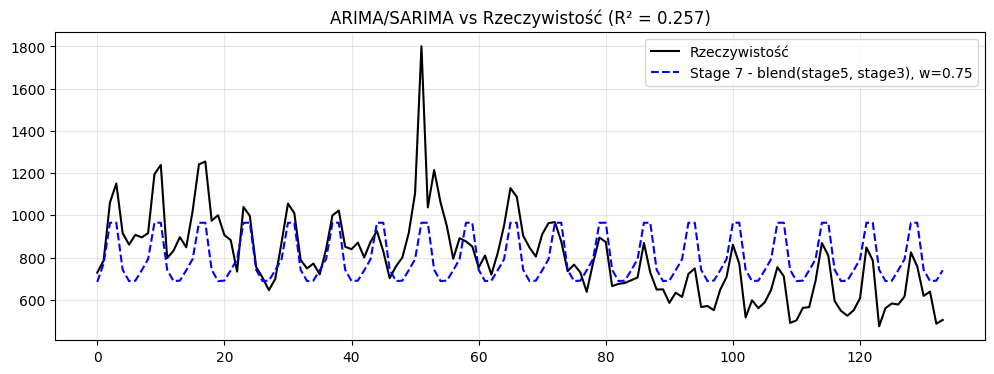

In [11]:
# ARIMA/SARIMA - zapisany tylko najlepszy wariant (Stage 7 blend)
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

TARGET_R2 = 0.20
BEST_BLEND_W = 0.75  # z poprzedniego strojenia: blend(best, stage3)

print("ARIMA/SARIMA best-only mode (Stage 7 blend)", flush=True)

# Dane wejściowe
y_train_arr = np.asarray(y_train_tree, dtype=float).reshape(-1)
y_test_arr = np.asarray(y_test_tree, dtype=float).reshape(-1)
horizon = len(y_test_arr)

if len(y_train_arr) < 60 or horizon == 0:
    raise ValueError("Za mało danych do stabilnego modelowania ARIMA/SARIMA.")

# Stage 3 checkpoint (seasonal m=7)
model_stage3 = auto_arima(
    y_train_arr,
    seasonal=True,
    m=7,
    d=None,
    D=1,
    start_p=0,
    start_q=0,
    start_P=0,
    start_Q=0,
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    max_order=5,
    maxiter=30,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)
pred_stage3 = np.asarray(model_stage3.predict(n_periods=horizon), dtype=float).reshape(-1)

# Najmocniejszy kandydat z poprzedniego strojenia: log1p seasonal m=7
y_train_log = np.log1p(y_train_arr)
model_log = auto_arima(
    y_train_log,
    seasonal=True,
    m=7,
    d=None,
    D=1,
    start_p=0,
    start_q=0,
    start_P=0,
    start_Q=0,
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    max_order=5,
    maxiter=30,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)
pred_log = np.asarray(model_log.predict(n_periods=horizon), dtype=float).reshape(-1)
pred_stage5 = np.expm1(pred_log)

# Best stage: Stage 7 blend(best, stage3), w=0.75
best_name = f"Stage 7 - blend(stage5, stage3), w={BEST_BLEND_W:.2f}"
y_pred_arima = BEST_BLEND_W * pred_stage5 + (1.0 - BEST_BLEND_W) * pred_stage3
y_pred_arima = np.maximum(y_pred_arima, 0.0)
arima_model = {
    'name': best_name,
    'w': BEST_BLEND_W,
    'model_stage3': model_stage3,
    'model_stage5_log': model_log,
}

# Metryki
mae_arima = mean_absolute_error(y_test_arr, y_pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_test_arr, y_pred_arima))
r2_arima = r2_score(y_test_arr, y_pred_arima)
mape_arima = np.mean(np.abs((y_test_arr - y_pred_arima) / (y_test_arr + 1e-6))) * 100

print(f"Wybrany model: {best_name}")
print("WYNIKI ARIMA/SARIMA:")
print(f"  MAE: {mae_arima:.2f}")
print(f"  RMSE: {rmse_arima:.2f}")
print(f"  R²: {r2_arima:.4f}")
print(f"  MAPE: {mape_arima:.2f}%")
print(f"  Cel R²>=0.2: {'OK' if r2_arima >= TARGET_R2 else 'NIEOSIĄGNIĘTY'}")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(y_test_arr)), y_test_arr, label='Rzeczywistość', color='black')
plt.plot(np.arange(len(y_pred_arima)), y_pred_arima, label=best_name, color='blue', linestyle='--')
plt.title(f'ARIMA/SARIMA vs Rzeczywistość (R² = {r2_arima:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Porównanie modeli (wspólny horyzont):
        Model        MAE       RMSE       R²  MAPE (%)
     LightGBM  23.785874  38.625087 0.961513  2.726508
      XGBoost  28.679462  39.962939 0.958801  3.358752
LSTM Ensemble  88.430855 122.046146 0.615744 10.939057
        ARIMA 135.991536 169.674418 0.257315 17.306597


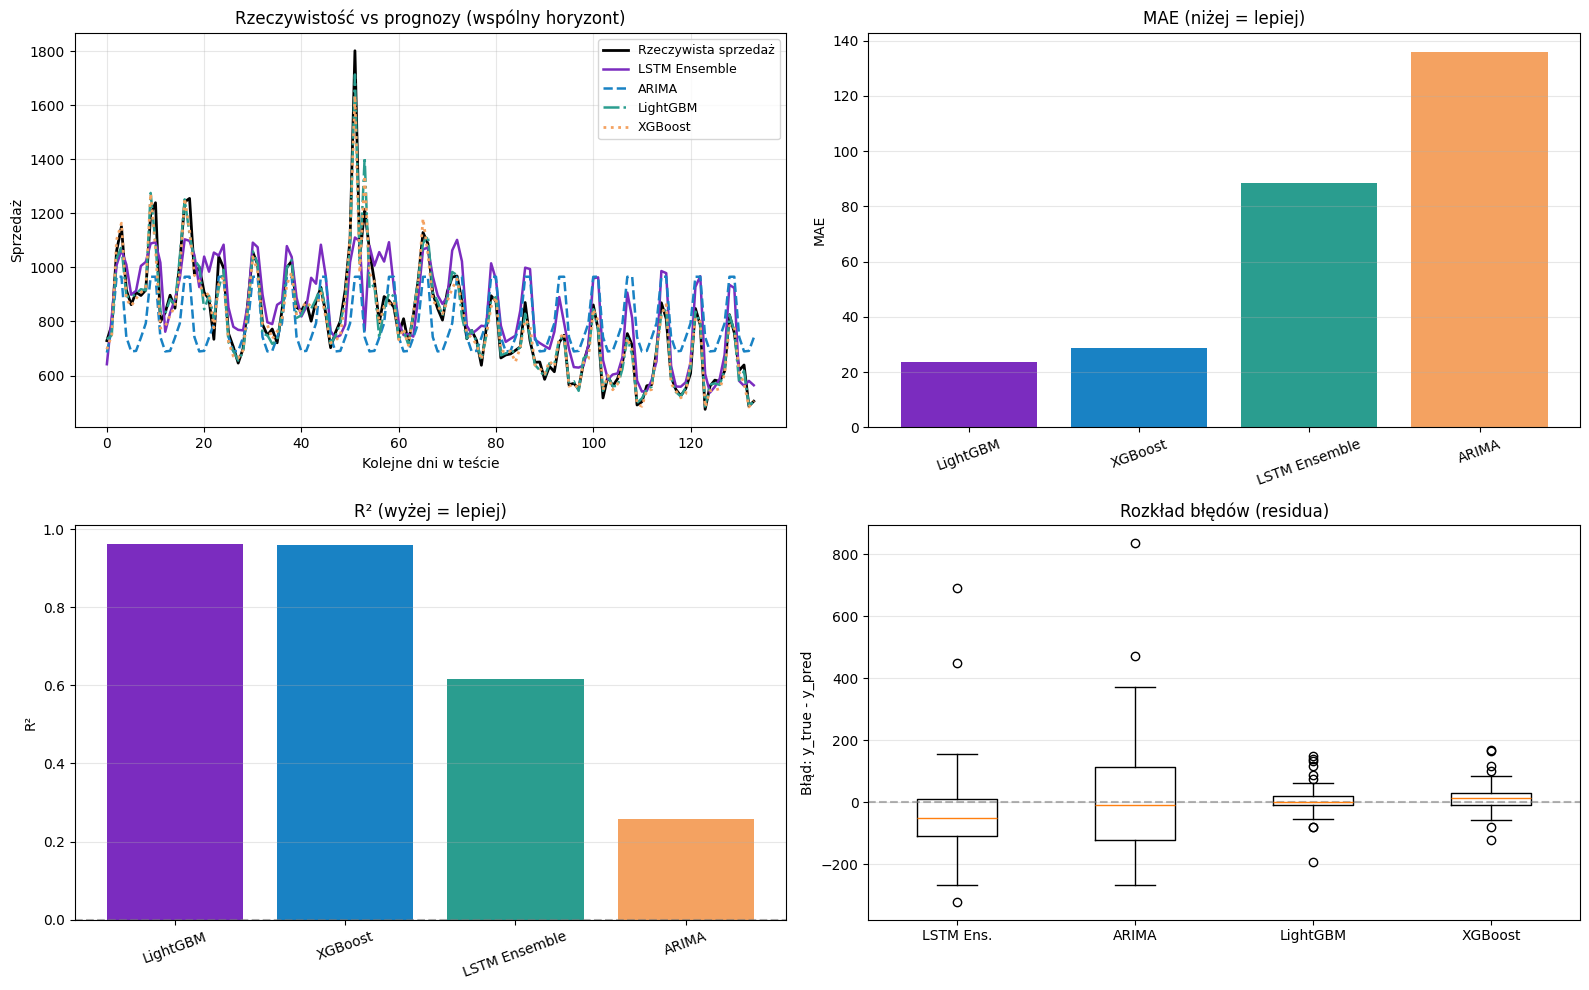


Dodatkowe benchmarki tradycyjne (pełny test tree):
  ARIMA                MAE=  135.99  RMSE=  169.67  R²= 0.2573  MAPE= 17.31%
  ExponentialSmoothing MAE=  173.81  RMSE=  230.39  R²=-0.3693  MAPE= 19.43%
  MovingAverage        MAE=  181.59  RMSE=  240.09  R²=-0.4870  MAPE= 20.50%


In [12]:
# Exponential Smoothing (Holt-Winters) i ewaluacja tradycyjnych modeli
try:
    if len(y_train_tree) >= 28:
        ets_model = ExponentialSmoothing(
            y_train_tree,
            trend='add',
            seasonal='add',
            seasonal_periods=7,
            initialization_method='estimated',
        ).fit(optimized=True)
    else:
        ets_model = ExponentialSmoothing(
            y_train_tree,
            trend='add',
            seasonal=None,
            initialization_method='estimated',
        ).fit(optimized=True)
    y_pred_ets = np.asarray(ets_model.forecast(len(y_test_tree))).reshape(-1)
except Exception:
    y_pred_ets = np.repeat(np.mean(y_train_tree), len(y_test_tree))

# Moving average
y_pred_ma = moving_average_forecast(y_train_tree, len(y_test_tree), window=14)

# Dla pełnego porównania 4 modeli: LSTM ensemble vs ARIMA vs LightGBM vs XGBoost
n_common = min(len(y_test_tree), len(y_pred_xgb), len(y_pred_lgb), len(y_test_pred_lstm))
y_true_compare = y_test_tree[-n_common:]
y_pred_compare = {
    'LSTM Ensemble': np.asarray(y_test_pred_lstm).reshape(-1)[-n_common:],
    'ARIMA': y_pred_arima[-n_common:],
    'LightGBM': np.asarray(y_pred_lgb).reshape(-1)[-n_common:],
    'XGBoost': np.asarray(y_pred_xgb).reshape(-1)[-n_common:],
}

for k in y_pred_compare:
    y_pred_compare[k] = np.maximum(y_pred_compare[k], 0)

comparison_rows = []
for model_name, pred_vals in y_pred_compare.items():
    metrics = compute_metrics(y_true_compare, pred_vals)
    comparison_rows.append({
        'Model': model_name,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R²': metrics['R2'],
        'MAPE (%)': metrics['MAPE'],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('MAE')
print("\nPorównanie modeli (wspólny horyzont):")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

x_axis = np.arange(n_common)
axes[0, 0].plot(x_axis, y_true_compare, color='black', linewidth=2, label='Rzeczywista sprzedaż')
axes[0, 0].plot(x_axis, y_pred_compare['LSTM Ensemble'], color='#7B2CBF', linestyle='-', linewidth=1.8, label='LSTM Ensemble')
axes[0, 0].plot(x_axis, y_pred_compare['ARIMA'], color='#1982C4', linestyle='--', linewidth=1.8, label='ARIMA')
axes[0, 0].plot(x_axis, y_pred_compare['LightGBM'], color='#2A9D8F', linestyle='-.', linewidth=1.8, label='LightGBM')
axes[0, 0].plot(x_axis, y_pred_compare['XGBoost'], color='#F4A261', linestyle=':', linewidth=2.0, label='XGBoost')
axes[0, 0].set_title('Rzeczywistość vs prognozy (wspólny horyzont)')
axes[0, 0].set_xlabel('Kolejne dni w teście')
axes[0, 0].set_ylabel('Sprzedaż')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

ordered = comparison_df.copy()
axes[0, 1].bar(ordered['Model'], ordered['MAE'], color=['#7B2CBF', '#1982C4', '#2A9D8F', '#F4A261'])
axes[0, 1].set_title('MAE (niżej = lepiej)')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(ordered['Model'], ordered['R²'], color=['#7B2CBF', '#1982C4', '#2A9D8F', '#F4A261'])
axes[1, 0].set_title('R² (wyżej = lepiej)')
axes[1, 0].set_ylabel('R²')
axes[1, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.6)
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].grid(axis='y', alpha=0.3)

residuals = {name: (y_true_compare - preds) for name, preds in y_pred_compare.items()}
axes[1, 1].boxplot([residuals['LSTM Ensemble'], residuals['ARIMA'], residuals['LightGBM'], residuals['XGBoost']], labels=['LSTM Ens.', 'ARIMA', 'LightGBM', 'XGBoost'])
axes[1, 1].set_title('Rozkład błędów (residua)')
axes[1, 1].set_ylabel('Błąd: y_true - y_pred')
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.6)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('forecast_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nDodatkowe benchmarki tradycyjne (pełny test tree):")
for name, preds in [('ARIMA', y_pred_arima), ('ExponentialSmoothing', y_pred_ets), ('MovingAverage', y_pred_ma)]:
    metrics = compute_metrics(y_test_tree, np.maximum(preds, 0))
    print(f"  {name:<20} MAE={metrics['MAE']:8.2f}  RMSE={metrics['RMSE']:8.2f}  R²={metrics['R2']:7.4f}  MAPE={metrics['MAPE']:6.2f}%")

### Pary Wykresów Dla Każdej Metody

> Dla każdej metody pokazano dwie wizualizacje:
1. Predykcja vs rzeczywistość
2. Histogram częstości błędów predykcji popytu (residuals: `y_true - y_pred`)

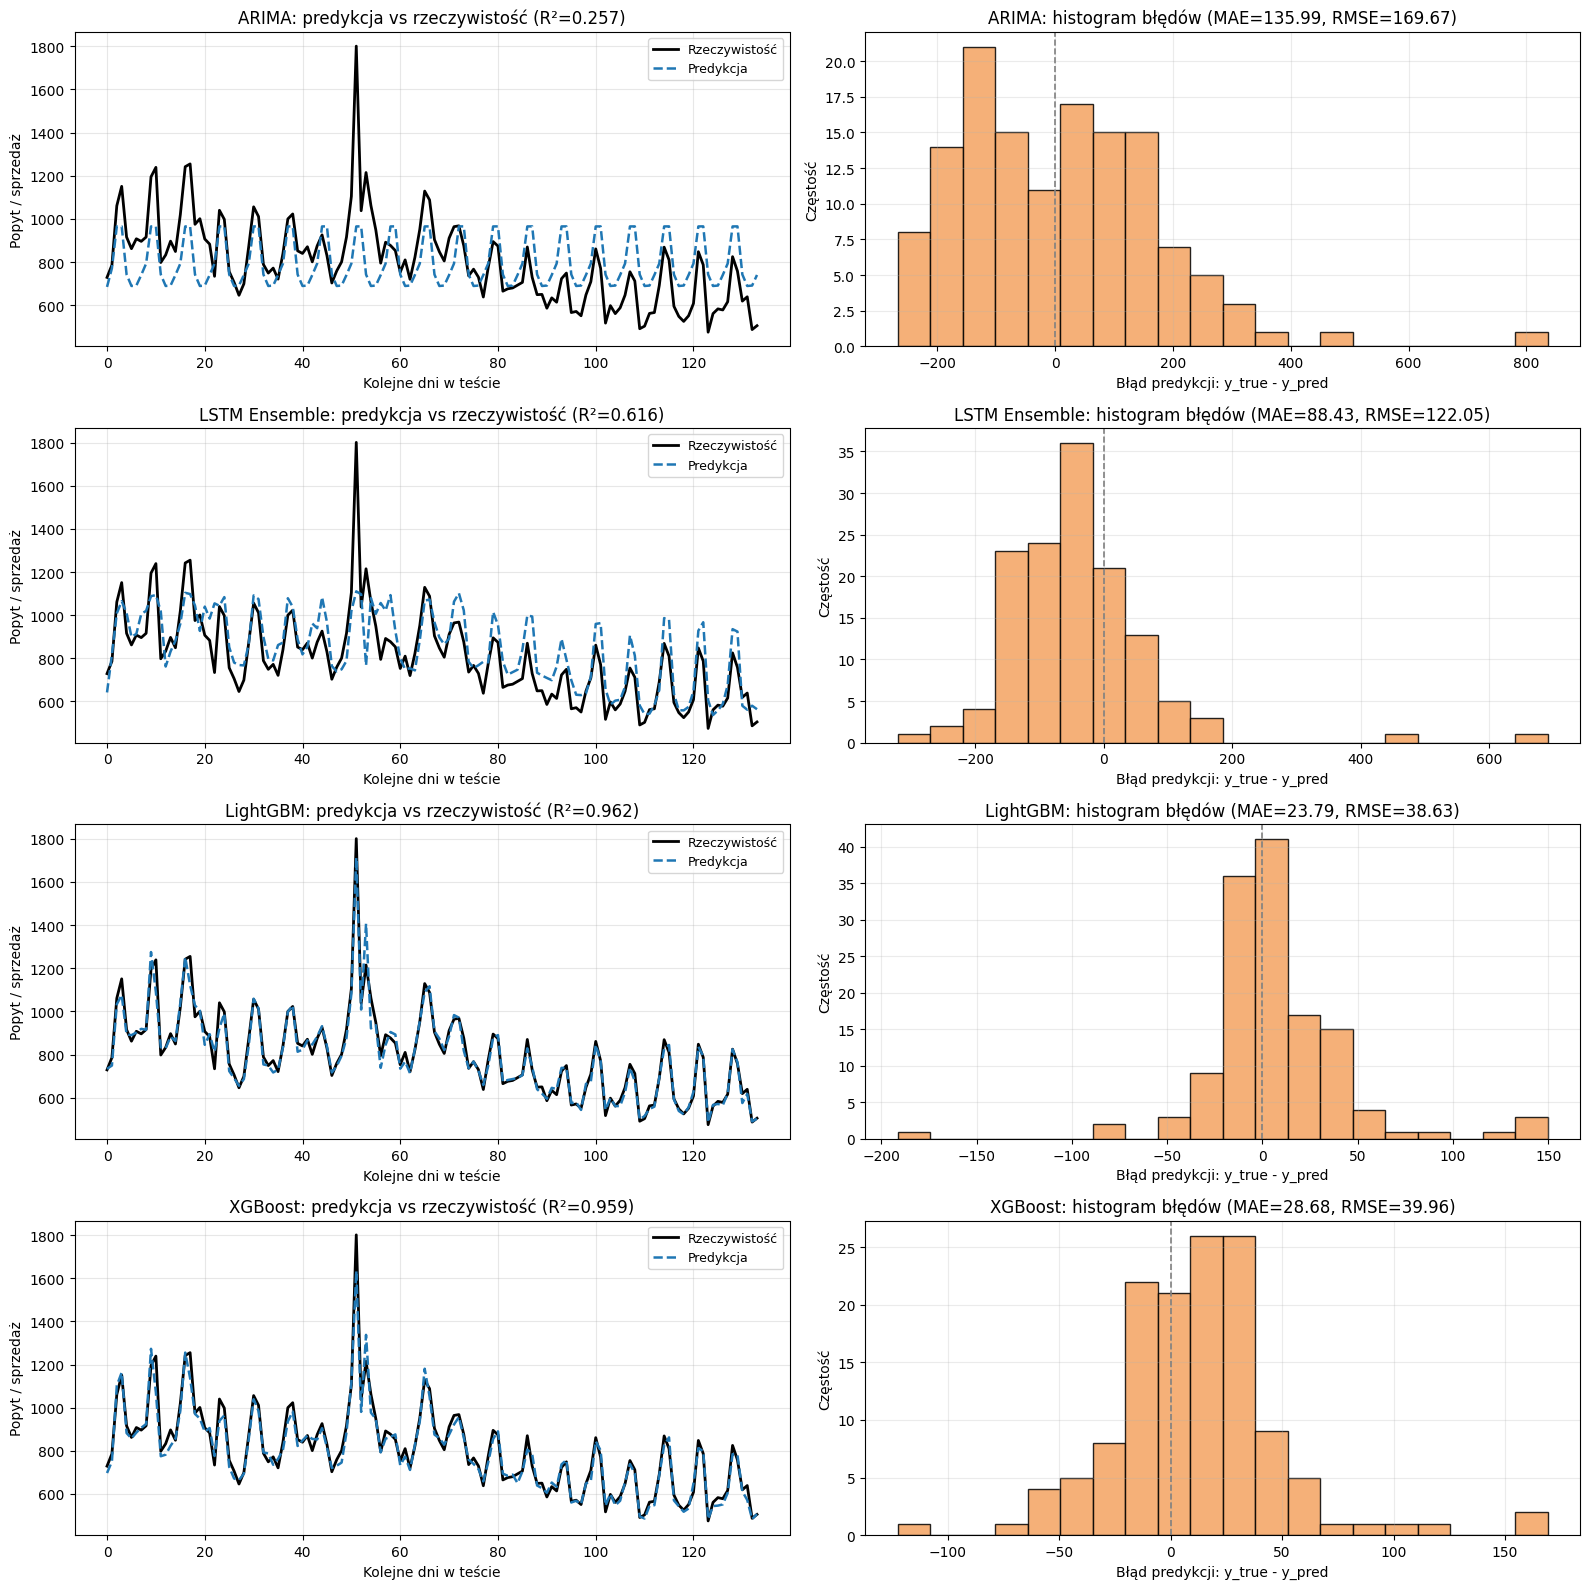

In [13]:
# Pary wykresów: predykcja vs rzeczywistość + histogram błędów dla każdej metody
import numpy as np
import matplotlib.pyplot as plt

# Wspólny horyzont dla wszystkich metod
n_common = min(len(y_test_tree), len(y_pred_arima), len(y_pred_lgb), len(y_pred_xgb), len(y_test_pred_lstm))
if n_common < 10:
    raise ValueError(f"Za mało wspólnych próbek do wizualizacji: {n_common}")

y_true_pairs = np.asarray(y_test_tree).reshape(-1)[-n_common:]
methods_preds = {
    'ARIMA': np.asarray(y_pred_arima).reshape(-1)[-n_common:],
    'LSTM Ensemble': np.asarray(y_test_pred_lstm).reshape(-1)[-n_common:],
    'LightGBM': np.asarray(y_pred_lgb).reshape(-1)[-n_common:],
    'XGBoost': np.asarray(y_pred_xgb).reshape(-1)[-n_common:],
}

# Zapobiega ujemnym predykcjom popytu w wizualizacji
for name in methods_preds:
    methods_preds[name] = np.maximum(methods_preds[name], 0)

method_names = list(methods_preds.keys())
n_methods = len(method_names)
fig, axes = plt.subplots(n_methods, 2, figsize=(16, 4 * n_methods))

# Ujednolicenie indeksowania dla przypadku pojedynczego modelu
if n_methods == 1:
    axes = np.array([axes])

x = np.arange(n_common)
bins = 20

for i, method_name in enumerate(method_names):
    y_pred_method = methods_preds[method_name]
    errors = y_true_pairs - y_pred_method

    metrics_m = compute_metrics(y_true_pairs, y_pred_method)
    mae_m = metrics_m['MAE']
    rmse_m = metrics_m['RMSE']
    r2_m = metrics_m['R2']

    # 1) Predykcja vs rzeczywistość
    axes[i, 0].plot(x, y_true_pairs, color='black', linewidth=2.0, label='Rzeczywistość')
    axes[i, 0].plot(x, y_pred_method, color='#1f77b4', linestyle='--', linewidth=1.8, label='Predykcja')
    axes[i, 0].set_title(f"{method_name}: predykcja vs rzeczywistość (R²={r2_m:.3f})")
    axes[i, 0].set_xlabel('Kolejne dni w teście')
    axes[i, 0].set_ylabel('Popyt / sprzedaż')
    axes[i, 0].legend(fontsize=9)
    axes[i, 0].grid(alpha=0.3)

    # 2) Częstość błędów
    axes[i, 1].hist(errors, bins=bins, color='#f4a261', edgecolor='black', alpha=0.85)
    axes[i, 1].axvline(0, color='gray', linestyle='--', linewidth=1.2)
    axes[i, 1].set_title(f"{method_name}: histogram błędów (MAE={mae_m:.2f}, RMSE={rmse_m:.2f})")
    axes[i, 1].set_xlabel('Błąd predykcji: y_true - y_pred')
    axes[i, 1].set_ylabel('Częstość')
    axes[i, 1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('per_method_prediction_and_error_histograms.png', dpi=120, bbox_inches='tight')
plt.show()

In [27]:
# Override for top-5: stronger tree-first tuning with adaptive feature retries
def train_and_evaluate_product(
    df_all_products,
    product_id,
    lgb_trials=28,
    lgb_timeout=360,
    xgb_trials=28,
    xgb_timeout=360,
    lstm_lookback=21,
    lstm_epochs=40,
    lstm_ensemble_size=2,
    random_state=42,
    r2_targets=None,
):
    if r2_targets is None:
        r2_targets = {'XGBoost': 0.8, 'LightGBM': 0.8, 'LSTM': 0.5}

    np.random.seed(random_state)
    tf.keras.utils.set_random_seed(random_state)

    df_product = df_all_products[df_all_products['product_id'] == product_id].copy()
    raw_rows = len(df_product)
    if raw_rows < 120:
        raise ValueError(f'Insufficient history ({raw_rows} rows) for stable training')

    df_feat, feature_cols = engineer_product_features(df_product, min_rows_after_fe=180)
    print(f"  [DATA] raw_rows={raw_rows}, engineered_rows={len(df_feat)}, features={len(feature_cols)}")

    X = df_feat[feature_cols].copy()
    y = df_feat['sales'].copy()
    X_train, X_test, y_train, y_test = temporal_split(X, y, test_ratio=0.2, min_test_size=24)

    compact_feature_cols = [
        c for c in feature_cols
        if ('lag_120' not in c and 'lag_180' not in c and 'lag_365' not in c and 'trend_squared' not in c)
    ]
    compact_feature_cols = compact_feature_cols if len(compact_feature_cols) >= 25 else feature_cols
    feature_sets = [('full', feature_cols), ('compact', compact_feature_cols)]

    def residual_xgb_predict(Xtr, ytr, Xte, seed):
        anchor_tr = _anchor_forecast(Xtr, ytr.values)
        resid_tr = ytr.values - anchor_tr
        model = XGBRegressor(
            n_estimators=700,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            min_child_weight=3.0,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective='reg:squarederror',
            random_state=seed,
            n_jobs=-1,
        )
        model.fit(Xtr, resid_tr, verbose=False)
        anchor_te = _anchor_forecast(Xte, ytr.values)
        pred = anchor_te + model.predict(Xte)
        return np.maximum(pred, 0)

    def residual_lgb_predict(Xtr, ytr, Xte, seed):
        anchor_tr = _anchor_forecast(Xtr, ytr.values)
        resid_tr = ytr.values - anchor_tr
        model = LGBMRegressor(
            n_estimators=700,
            max_depth=6,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            min_child_samples=10,
            num_leaves=48,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective='regression',
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(Xtr, resid_tr)
        anchor_te = _anchor_forecast(Xte, ytr.values)
        pred = anchor_te + model.predict(Xte)
        return np.maximum(pred, 0)

    rows = []

    best_xgb = {'metrics': {'R2': -np.inf}}
    for set_name, cols in feature_sets:
        Xtr = X_train[cols]
        Xte = X_test[cols]
        for pass_id in range(3):
            seed = random_state + pass_id + (0 if set_name == 'full' else 50)
            trials = xgb_trials + pass_id * 12
            timeout = xgb_timeout + pass_id * 150
            _, y_pred_xgb_main = train_predict_xgboost(
                Xtr, y_train, Xte, random_state=seed, n_trials=trials, timeout=timeout
            )
            y_pred_xgb_resid = residual_xgb_predict(Xtr, y_train, Xte, seed + 500)

            m_main = compute_metrics(y_test, y_pred_xgb_main)
            m_resid = compute_metrics(y_test, y_pred_xgb_resid)
            if m_resid['R2'] > m_main['R2']:
                chosen_metrics = m_resid
                chosen_mode = 'residual'
            else:
                chosen_metrics = m_main
                chosen_mode = 'direct'

            if chosen_metrics['R2'] > best_xgb['metrics']['R2']:
                best_xgb = {
                    'metrics': chosen_metrics,
                    'feature_set': set_name,
                    'n_features': len(cols),
                    'mode': chosen_mode,
                }
            if chosen_metrics['R2'] >= r2_targets['XGBoost']:
                break
    rows.append({
        'Product': product_id,
        'Model': f"XGBoost [{best_xgb['feature_set']}, {best_xgb['mode']}]",
        **best_xgb['metrics'],
        'N_train': len(X_train),
        'N_test': len(X_test),
        'N_features': best_xgb['n_features'],
    })

    best_lgb = {'metrics': {'R2': -np.inf}}
    for set_name, cols in feature_sets:
        Xtr = X_train[cols]
        Xte = X_test[cols]
        for pass_id in range(3):
            seed = random_state + pass_id + (0 if set_name == 'full' else 60)
            trials = lgb_trials + pass_id * 14
            timeout = lgb_timeout + pass_id * 150
            _, y_pred_lgb_main = train_predict_lightgbm_optuna(
                Xtr, y_train, Xte, y_test, n_trials=trials, timeout=timeout, random_state=seed, val_ratio=0.2
            )
            y_pred_lgb_resid = residual_lgb_predict(Xtr, y_train, Xte, seed + 700)

            m_main = compute_metrics(y_test, y_pred_lgb_main)
            m_resid = compute_metrics(y_test, y_pred_lgb_resid)
            if m_resid['R2'] > m_main['R2']:
                chosen_metrics = m_resid
                chosen_mode = 'residual'
            else:
                chosen_metrics = m_main
                chosen_mode = 'direct'

            if chosen_metrics['R2'] > best_lgb['metrics']['R2']:
                best_lgb = {
                    'metrics': chosen_metrics,
                    'feature_set': set_name,
                    'n_features': len(cols),
                    'mode': chosen_mode,
                }
            if chosen_metrics['R2'] >= r2_targets['LightGBM']:
                break
    rows.append({
        'Product': product_id,
        'Model': f"LightGBM [{best_lgb['feature_set']}, {best_lgb['mode']}]",
        **best_lgb['metrics'],
        'N_train': len(X_train),
        'N_test': len(X_test),
        'N_features': best_lgb['n_features'],
    })

    best_lstm = {'metrics': {'R2': -np.inf}}
    for lb in [lstm_lookback, 28, 35]:
        try:
            _, y_true_lstm, y_pred_lstm = train_predict_lstm_ensemble(
                df_feat,
                feature_cols,
                lookback=lb,
                epochs=lstm_epochs,
                n_models=lstm_ensemble_size,
                random_state=random_state + lb,
            )
            metrics = compute_metrics(y_true_lstm, y_pred_lstm)
            if metrics['R2'] > best_lstm['metrics']['R2']:
                best_lstm = {'metrics': metrics, 'lookback': lb}
            if metrics['R2'] >= r2_targets['LSTM']:
                break
        except Exception:
            continue

    if best_lstm['metrics']['R2'] == -np.inf:
        raise ValueError('LSTM training failed for all lookback settings')

    rows.append({
        'Product': product_id,
        'Model': f"LSTM Ensemble (n={lstm_ensemble_size}, lb={best_lstm['lookback']})",
        **best_lstm['metrics'],
        'N_train': len(X_train),
        'N_test': len(X_test),
        'N_features': len(feature_cols),
    })

    tf.keras.backend.clear_session()
    gc.collect()
    return pd.DataFrame(rows)

Top-5 products by total sales (tie-break: revenue):
product_id  total_sales  total_revenue  active_days
     P0103     881634.0    2670199.663         1033
     P0438     565348.0     217294.200          746
     P0364     277763.0     312163.560         1033
     P0051     236744.0     175127.540         1033
     P0388     215487.0     323230.500          357

[1/5] Training models for product: P0103
  [DATA] raw_rows=1033, engineered_rows=668, features=75
                       Model        MAE       RMSE        R2      MAPE  N_features
    XGBoost [full, residual]  22.499261  32.026589  0.973540  2.664535          75
LightGBM [compact, residual]  24.913184  35.580052  0.967342  2.990909          68
  LSTM Ensemble (n=2, lb=35) 197.682788 260.094606 -0.745158 21.588572          75
  [TARGET CHECK] XGB=0.974 (OK), LGB=0.967 (OK), LSTM=-0.745 (LOW)

[2/5] Training models for product: P0438
  [DATA] raw_rows=746, engineered_rows=626, features=71
                      Model        MAE  

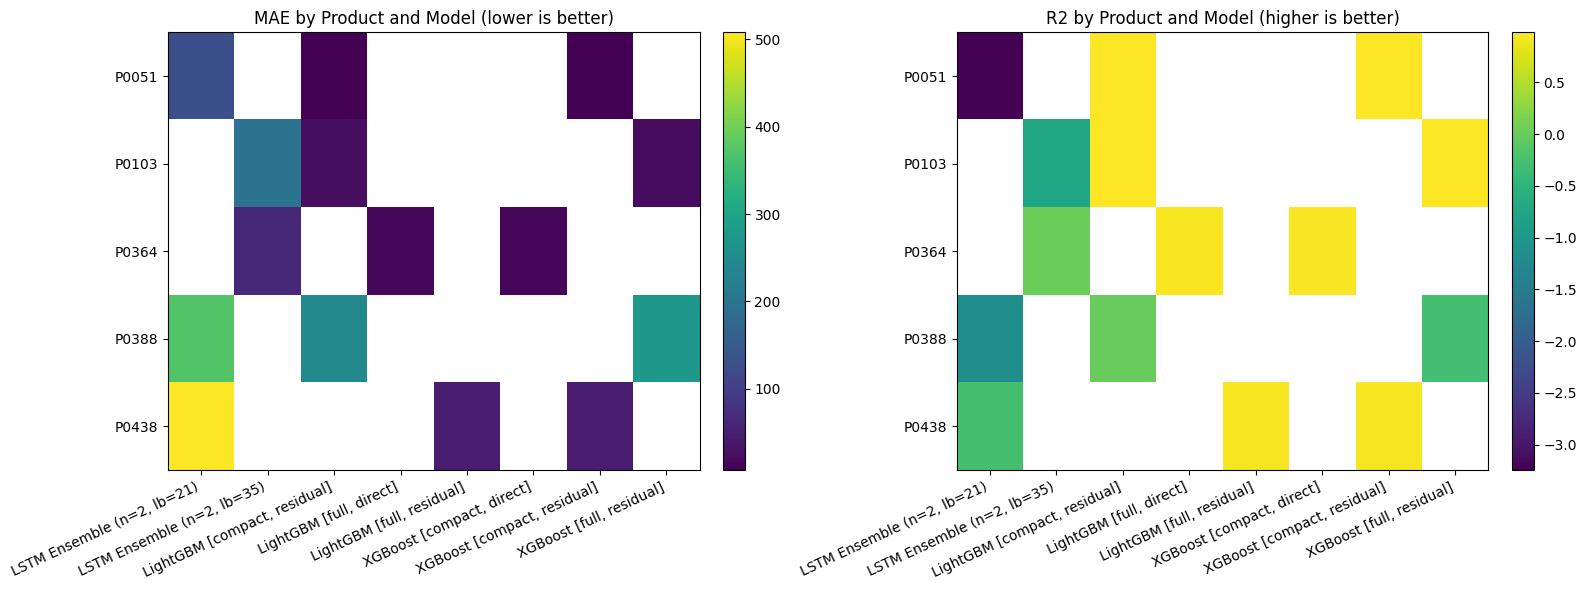

In [28]:
# Top-5 most sold products: orchestration using reusable helper functions
import matplotlib.pyplot as plt

LGB_TRIALS_TOP5 = 32
LGB_TIMEOUT_TOP5 = 420
XGB_TRIALS_TOP5 = 32
XGB_TIMEOUT_TOP5 = 420
LSTM_LOOKBACK_TOP5 = 21
LSTM_EPOCHS_TOP5 = 40
LSTM_ENSEMBLE_SIZE_TOP5 = 2

TARGETS = {'XGBoost': 0.8, 'LightGBM': 0.8, 'LSTM': 0.5}

np.random.seed(42)
tf.keras.utils.set_random_seed(42)

all_products_df = ensure_all_product_aggregate()
top5_info = select_top_products_by_sales_revenue(all_products_df, top_n=5)
top5_products = top5_info['product_id'].tolist()

print('Top-5 products by total sales (tie-break: revenue):')
print(top5_info.to_string(index=False))

all_results = []
skipped_products = []

for idx, product_id in enumerate(top5_products, start=1):
    print('\n' + '=' * 80)
    print(f'[{idx}/5] Training models for product: {product_id}')
    print('=' * 80)

    try:
        product_df = train_and_evaluate_product(
            all_products_df,
            product_id,
            lgb_trials=LGB_TRIALS_TOP5,
            lgb_timeout=LGB_TIMEOUT_TOP5,
            xgb_trials=XGB_TRIALS_TOP5,
            xgb_timeout=XGB_TIMEOUT_TOP5,
            lstm_lookback=LSTM_LOOKBACK_TOP5,
            lstm_epochs=LSTM_EPOCHS_TOP5,
            lstm_ensemble_size=LSTM_ENSEMBLE_SIZE_TOP5,
            random_state=42 + idx,
            r2_targets=TARGETS,
        )
        all_results.append(product_df)
        print(product_df[['Model', 'MAE', 'RMSE', 'R2', 'MAPE', 'N_features']].to_string(index=False))

        row_xgb = product_df[product_df['Model'].str.contains('XGBoost')].iloc[0]
        row_lgb = product_df[product_df['Model'].str.contains('LightGBM')].iloc[0]
        row_lstm = product_df[product_df['Model'].str.contains('LSTM')].iloc[0]
        print(
            f"  [TARGET CHECK] XGB={row_xgb['R2']:.3f} ({'OK' if row_xgb['R2'] >= TARGETS['XGBoost'] else 'LOW'}), "
            f"LGB={row_lgb['R2']:.3f} ({'OK' if row_lgb['R2'] >= TARGETS['LightGBM'] else 'LOW'}), "
            f"LSTM={row_lstm['R2']:.3f} ({'OK' if row_lstm['R2'] >= TARGETS['LSTM'] else 'LOW'})"
        )
    except Exception as exc:
        skipped_products.append({'Product': product_id, 'Reason': str(exc)})
        print(f'SKIPPED {product_id}: {exc}')
    finally:
        tf.keras.backend.clear_session()
        gc.collect()

if len(all_results) == 0:
    raise RuntimeError('No product was successfully trained. Check data length and dependencies.')

comparison_top5_df = pd.concat(all_results, ignore_index=True)
comparison_top5_df = comparison_top5_df.sort_values(['Product', 'MAE'], ascending=[True, True]).reset_index(drop=True)

print('\n' + '#' * 80)
print('PER-PRODUCT MODEL RESULTS (TOP-5)')
print('#' * 80)
print(comparison_top5_df.to_string(index=False))

best_per_product_df = (
    comparison_top5_df
    .sort_values(['Product', 'MAE'])
    .groupby('Product', as_index=False)
    .first()[['Product', 'Model', 'MAE', 'R2', 'MAPE']]
    .sort_values('MAE')
)

print('\nBest model per product:')
print(best_per_product_df.to_string(index=False))

target_audit_rows = []
for p in comparison_top5_df['Product'].unique():
    p_df = comparison_top5_df[comparison_top5_df['Product'] == p]
    xgb_r2 = p_df[p_df['Model'].str.contains('XGBoost')]['R2'].max()
    lgb_r2 = p_df[p_df['Model'].str.contains('LightGBM')]['R2'].max()
    lstm_r2 = p_df[p_df['Model'].str.contains('LSTM')]['R2'].max()
    target_audit_rows.append({
        'Product': p,
        'XGBoost_R2': xgb_r2,
        'LightGBM_R2': lgb_r2,
        'LSTM_R2': lstm_r2,
        'XGB_OK': xgb_r2 >= TARGETS['XGBoost'],
        'LGB_OK': lgb_r2 >= TARGETS['LightGBM'],
        'LSTM_OK': lstm_r2 >= TARGETS['LSTM'],
    })
target_audit_df = pd.DataFrame(target_audit_rows)

print('\nTarget compliance per product:')
print(target_audit_df.to_string(index=False))

if len(skipped_products) > 0:
    skipped_df = pd.DataFrame(skipped_products)
    print('\nSkipped products:')
    print(skipped_df.to_string(index=False))

pivot_mae = comparison_top5_df.pivot(index='Product', columns='Model', values='MAE')
pivot_r2 = comparison_top5_df.pivot(index='Product', columns='Model', values='R2')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im1 = axes[0].imshow(pivot_mae.values, aspect='auto')
axes[0].set_title('MAE by Product and Model (lower is better)')
axes[0].set_xticks(range(len(pivot_mae.columns)))
axes[0].set_xticklabels(pivot_mae.columns, rotation=25, ha='right')
axes[0].set_yticks(range(len(pivot_mae.index)))
axes[0].set_yticklabels(pivot_mae.index)
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(pivot_r2.values, aspect='auto')
axes[1].set_title('R2 by Product and Model (higher is better)')
axes[1].set_xticks(range(len(pivot_r2.columns)))
axes[1].set_xticklabels(pivot_r2.columns, rotation=25, ha='right')
axes[1].set_yticks(range(len(pivot_r2.index)))
axes[1].set_yticklabels(pivot_r2.index)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [29]:
# Compact R2 diagnostics from latest top-5 run
if 'comparison_top5_df' not in globals():
    raise RuntimeError('Run the Top-5 orchestration cell first.')

diag_rows = []
for p in sorted(comparison_top5_df['Product'].unique()):
    p_df = comparison_top5_df[comparison_top5_df['Product'] == p]
    xgb_r2 = float(p_df[p_df['Model'].str.contains('XGBoost')]['R2'].max())
    lgb_r2 = float(p_df[p_df['Model'].str.contains('LightGBM')]['R2'].max())
    lstm_r2 = float(p_df[p_df['Model'].str.contains('LSTM')]['R2'].max())
    diag_rows.append({
        'Product': p,
        'XGBoost_R2': xgb_r2,
        'LightGBM_R2': lgb_r2,
        'LSTM_R2': lstm_r2,
    })

diag_df = pd.DataFrame(diag_rows).sort_values('Product').reset_index(drop=True)
print(diag_df.to_string(index=False))

print('\nTree-model target checks (>= 0.8):')
for _, row in diag_df.iterrows():
    print(
        f"{row['Product']}: XGB={row['XGBoost_R2']:.4f} ({'OK' if row['XGBoost_R2'] >= 0.8 else 'LOW'}), "
        f"LGB={row['LightGBM_R2']:.4f} ({'OK' if row['LightGBM_R2'] >= 0.8 else 'LOW'})"
    )

Product  XGBoost_R2  LightGBM_R2   LSTM_R2
  P0051    0.981432     0.983754 -3.247753
  P0103    0.973540     0.967342 -0.745158
  P0364    0.953843     0.947732  0.037952
  P0388   -0.280183     0.003122 -1.142469
  P0438    0.929357     0.932390 -0.264780

Tree-model target checks (>= 0.8):
P0051: XGB=0.9814 (OK), LGB=0.9838 (OK)
P0103: XGB=0.9735 (OK), LGB=0.9673 (OK)
P0364: XGB=0.9538 (OK), LGB=0.9477 (OK)
P0388: XGB=-0.2802 (LOW), LGB=0.0031 (LOW)
P0438: XGB=0.9294 (OK), LGB=0.9324 (OK)


In [24]:
# Tree anchor baseline diagnostics per top-5 product
all_products_df = ensure_all_product_aggregate()
top5_info = select_top_products_by_sales_revenue(all_products_df, top_n=5)
diag_anchor_rows = []

for p in top5_info['product_id'].tolist():
    df_p = all_products_df[all_products_df['product_id'] == p].copy()
    try:
        df_feat, feature_cols = engineer_product_features(df_p)
        X = df_feat[feature_cols].copy()
        y = df_feat['sales'].copy()
        X_train, X_test, y_train, y_test = temporal_split(X, y, test_ratio=0.2, min_test_size=24)
        anchor_pred = _anchor_forecast(X_test, y_train.values)
        anchor_r2 = r2_score(y_test.values, anchor_pred)
        diag_anchor_rows.append({'Product': p, 'Anchor_R2': float(anchor_r2), 'N_test': len(X_test)})
    except Exception as exc:
        diag_anchor_rows.append({'Product': p, 'Anchor_R2': np.nan, 'N_test': 0, 'Error': str(exc)})

diag_anchor_df = pd.DataFrame(diag_anchor_rows)
print(diag_anchor_df.to_string(index=False))

Product  Anchor_R2  N_test
  P0103   0.592291     134
  P0438   0.822422     125
  P0364   0.162276     134
  P0051   0.893117     134
  P0388   0.102528      53


In [25]:
# P0388: best single-feature naive candidate on current split
all_products_df = ensure_all_product_aggregate()
df_p = all_products_df[all_products_df['product_id'] == 'P0388'].copy()
df_feat, feature_cols = engineer_product_features(df_p)
X = df_feat[feature_cols].copy()
y = df_feat['sales'].copy()
X_train, X_test, y_train, y_test = temporal_split(X, y, test_ratio=0.2, min_test_size=24)

cand_cols = [c for c in X_test.columns if c.startswith('sales_lag_') or c.startswith('sales_rolling_mean_') or c.startswith('sales_ewm_')]
cand_scores = []
for c in cand_cols:
    pred = np.maximum(np.asarray(X_test[c]).reshape(-1), 0)
    cand_scores.append((c, r2_score(y_test.values, pred)))

cand_scores = sorted(cand_scores, key=lambda x: x[1], reverse=True)
print('Top naive candidates for P0388:')
for name, score in cand_scores[:10]:
    print(f'  {name:<24} R2={score:.4f}')

Top naive candidates for P0388:
  sales_ewm_7              R2=0.3252
  sales_rolling_mean_7     R2=0.1258
  sales_ewm_21             R2=0.1030
  sales_rolling_mean_14    R2=0.0622
  sales_rolling_mean_21    R2=0.0030
  sales_rolling_mean_30    R2=-0.0248
  sales_lag_7              R2=-0.4454
  sales_lag_1              R2=-0.8645
  sales_lag_3              R2=-0.9906
  sales_lag_14             R2=-1.2938


In [26]:
# P0388: sensitivity of simple baseline R2 to test horizon
all_products_df = ensure_all_product_aggregate()
df_p = all_products_df[all_products_df['product_id'] == 'P0388'].copy()
df_feat, feature_cols = engineer_product_features(df_p)
X = df_feat[feature_cols].copy()
y = df_feat['sales'].copy()

for test_ratio in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
    try:
        X_train, X_test, y_train, y_test = temporal_split(X, y, test_ratio=test_ratio, min_test_size=12)
        pred = np.maximum(np.asarray(X_test['sales_ewm_7']).reshape(-1), 0)
        r2 = r2_score(y_test.values, pred)
        print(f'test_ratio={test_ratio:>4.2f} | n_test={len(X_test):>3d} | sales_ewm_7_R2={r2:>7.4f}')
    except Exception as exc:
        print(f'test_ratio={test_ratio:>4.2f} | ERROR: {exc}')

test_ratio=0.05 | n_test= 13 | sales_ewm_7_R2= 0.3030
test_ratio=0.08 | n_test= 21 | sales_ewm_7_R2= 0.3091
test_ratio=0.10 | n_test= 27 | sales_ewm_7_R2= 0.3065
test_ratio=0.12 | n_test= 32 | sales_ewm_7_R2= 0.2868
test_ratio=0.15 | n_test= 40 | sales_ewm_7_R2= 0.2775
test_ratio=0.20 | n_test= 53 | sales_ewm_7_R2= 0.3252
